In [1]:
# ==============================================================================
# 0. PERSIAPAN LINGKUNGAN (ENVIRONMENT SETUP - REVISI TOTAL)
# ==============================================================================

# 1. Library Dasar dan Manipulasi Konten
import os
import re
import gc
import numpy as np
import pandas as pd
from collections import Counter

# 2. Visualisasi Grafik (Bab 4 Dokumentasi)
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Natural Language Processing (NLP) Bahasa Indonesia
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 4. Ekstraksi Fitur & Teknik Penyeimbangan Kelas (SMOTE)
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 5. Model Naive Bayes & Manajemen Validasi K-Fold
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict

# 6. Metrik Evaluasi Kinerja (Robust Metrics)
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 7. Utilitas Data Sourcing
import kagglehub

# Tahap 1: Akuisisi & Eksplorasi Data
Stratified Sampling, Pelabelan Data, Analisis Imbalance dan Veracity awal.

In [2]:
# ==============================================================================
# TAHAP 1: AKUISISI DAN EKSPLORASI DATA
# ==============================================================================

# --- 1.1 Akuisisi Dataset dari Kaggle ---
# Mengunduh dataset ulasan produk Tokopedia menggunakan KaggleHub API
path = kagglehub.dataset_download('farhan999/tokopedia-product-reviews')
print('Direktori Dataset:', path)

# --- 1.2 Verifikasi Struktur File ---
# Mengecek ketersediaan file CSV di dalam direktori untuk memastikan proses unduh berhasil
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Direktori Dataset: /home/miku/.cache/kagglehub/datasets/farhan999/tokopedia-product-reviews/versions/2
/home/miku/.cache/kagglehub/datasets/farhan999/tokopedia-product-reviews/versions/2/tokopedia-product-reviews-2019.csv


## Memuat dan Inspeksi Data
<h4>Memastikan data terbaca dan mengidentifikasi kolom ulasan (text) dan kolom rating (label)

In [3]:
# --- 1.3 Pembacaan Data dan Konfigurasi Display ---

# Mengatur tampilan output Pandas agar data ulasan tidak terpotong saat inspeksi manual
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Mendefinisikan lokasi file CSV hasil unduhan
csv_file_path = os.path.join(path, 'tokopedia-product-reviews-2019.csv')

# Memuat dataset ke dalam DataFrame Pandas dengan pengecekan keberadaan file
if os.path.exists(csv_file_path):
    df = pd.read_csv(csv_file_path)
    print(f"Berhasil memuat dataset. Total baris: {len(df)}")
    display(df.head())
else:
    print(f"Error: File tidak ditemukan di lokasi: {csv_file_path}")

Berhasil memuat dataset. Total baris: 40607


,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - Staples Gun 4-8 mm C Mart,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staples-dekorasi-staples-kayu-refill-8mm-staples-gun-4-8...
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-...
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-...
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; OSSEL 1022J,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-staples-tembak-air-nailer-gun-ossel-1022j
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gun Max t3-10 mb MAX,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-refill-staples-jok-kulit-motor-staple-gun-max-t3-10-m...


In [4]:
# --- 1.4 Inspeksi Struktur Dataset dan Kualitas Data ---

# Menampilkan informasi detail mengenai tipe data dan penggunaan memori tiap kolom
print("=== STRUKTUR DATASET ===")
df.info()

# Mengecek keberadaan nilai kosong (Missing Values) pada setiap fitur
# Hal ini penting untuk memastikan integritas data sebelum proses pembersihan
print("\n=== PENGECEKAN DATA KOSONG (MISSING VALUES) ===")
print(df.isnull().sum())

=== STRUKTUR DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    40607 non-null  int64 
 1   text          40607 non-null  object
 2   rating        40607 non-null  int64 
 3   category      40607 non-null  object
 4   product_name  40607 non-null  object
 5   product_id    40607 non-null  int64 
 6   sold          40593 non-null  object
 7   shop_id       40607 non-null  int64 
 8   product_url   40607 non-null  object
dtypes: int64(4), object(5)
memory usage: 2.8+ MB

=== PENGECEKAN DATA KOSONG (MISSING VALUES) ===
Unnamed: 0       0
text             0
rating           0
category         0
product_name     0
product_id       0
sold            14
shop_id          0
product_url      0
dtype: int64


In [5]:
# --- 1.5 Pernyataan Total Populasi Data ---

total_ulasan = len(df)
print(f"Total Data Awal: {total_ulasan} ulasan")

Total Data Awal: 40607 ulasan


In [6]:
# --- 1.6 Pengambilan Sampel untuk Simulasi Perhitungan Manual (Bab III) ---

# Membuat salinan untuk analisis teks
df_simulasi = df.copy()

# Menghitung panjang ulasan (jumlah kata)
df_simulasi['num_words'] = df_simulasi['text'].apply(lambda x: len(str(x).split()))

# Mengambil 2 contoh ulasan POSITIF (Rating 5) untuk simulasi perhitungan manual
# Sampel ini akan digunakan untuk mendemonstrasikan proses TF-IDF dan Naive Bayes di Bab III
print("=== SAMPEL SIMULASI: SENTIMEN POSITIF (2 DATA) ===")
simulasi_positif = df_simulasi[(df_simulasi['rating'] == 5) & 
                               (df_simulasi['num_words'] >= 3) & 
                               (df_simulasi['num_words'] <= 6)][['text', 'rating']].head(2)
display(simulasi_positif)

print("\n" + "="*45 + "\n")

# Mengambil 1 contoh ulasan NEGATIF (Rating 1) untuk simulasi perhitungan manual
# Digunakan untuk melihat perbedaan pembobotan kata terhadap label yang berbeda
print("=== SAMPEL SIMULASI: SENTIMEN NEGATIF (1 DATA) ===")
simulasi_negatif = df_simulasi[(df_simulasi['rating'] == 1) & 
                               (df_simulasi['num_words'] >= 3) & 
                               (df_simulasi['num_words'] <= 6)][['text', 'rating']].head(1)
display(simulasi_negatif)

=== SAMPEL SIMULASI: SENTIMEN POSITIF (2 DATA) ===


,text,rating
0,Barang sesuai pesanan dan cepat sampai,5
1,Barang bagus harga murah,5




=== SAMPEL SIMULASI: SENTIMEN NEGATIF (1 DATA) ===


,text,rating
93,barang yg dikirim tidak sesuai pesanan,1


## Cek & Hapus Duplikasi

In [7]:
# --- 1.7 Eliminasi Data Redundan (Deduplikasi) ---

# Menghitung jumlah data awal sebelum penghapusan duplikat
initial_len = len(df)

# Menghapus ulasan yang memiliki teks identik (duplikat/spam)
# Data duplikat dapat menyebabkan bias pada model karena frekuensi kata yang tidak natural
df = df.drop_duplicates(subset='text')

# Mencatat statistik pembersihan data
print(f"Jumlah Data Duplikat/Spam Dihapus : {initial_len - len(df)}")
print(f"Total Data Unik Tersisa          : {len(df)} baris")

Jumlah Data Duplikat/Spam Dihapus : 3306
Total Data Unik Tersisa          : 37301 baris


## Menghitung Distribusi Awal
<h4>Mendapatkan angka pasti untuk populasi sebelum sampling 20.000. Angka ini juga menunjukkan apakah terjadi Imbalance Class.</h4>

In [8]:
# --- 1.8 Analisis Distribusi Kelas Sentimen (Populasi Unik) ---

# Menghitung frekuensi absolut tiap skor rating (1-5)
dist_count = df['rating'].value_counts().sort_index() # sort_index agar berurutan 1-5

# Menghitung persentase proporsi tiap rating
dist_perc = df['rating'].value_counts(normalize=True).sort_index() * 100

# Menggabungkan hasil analisis ke dalam DataFrame ringkasan
dist_df = pd.DataFrame({
    'Jumlah': dist_count, 
    'Persentase (%)': dist_perc.round(2)
})

print("=== DISTRIBUSI RATING PADA DATA POPULASI (UNIK) ===")
display(dist_df)


=== DISTRIBUSI RATING PADA DATA POPULASI (UNIK) ===


,Jumlah,Persentase (%)
rating,,
1,531,1.42
2,380,1.02
3,1762,4.72
4,6995,18.75
5,27633,74.08


## Cleaning Ringan & Visualisasi Distribusi

In [9]:
# --- 1.9 Seleksi Fitur dan Finalisasi Data Sampel ---

# Menampilkan jumlah kolom awal sebelum penyaringan
print(f"Jumlah kolom sebelum seleksi: {len(df.columns)}")

# Hanya mengambil Kolom 'text' dan 'rating'
df_sample = df[['text', 'rating']].copy()

# Melakukan reset index agar urutan data kembali konsisten setelah proses sampling
df_sample = df_sample.reset_index(drop=True)

print(f"Jumlah kolom setelah seleksi: {len(df_sample.columns)}")
print("\n=== DATA SAMPEL AKHIR (SIAP UNTUK PREPROCESSING) ===")
display(df_sample.head())

Jumlah kolom sebelum seleksi: 9
Jumlah kolom setelah seleksi: 2

=== DATA SAMPEL AKHIR (SIAP UNTUK PREPROCESSING) ===


,text,rating
0,Barang sesuai pesanan dan cepat sampai,5
1,Barang bagus harga murah,5
2,Paket rapi...mantap....cepat....sampe ke tujuan,5
3,ya saya puas dgn barangnya,5
4,Responya luar biasa b mantap,5


=== TABEL DISTRIBUSI RATING ORDINAL (TOTAL DATA AKURAT) ===


,Rating,Jumlah,Persentase
0,1,531,1.42
1,2,380,1.02
2,3,1762,4.72
3,4,6995,18.75
4,5,27633,74.08


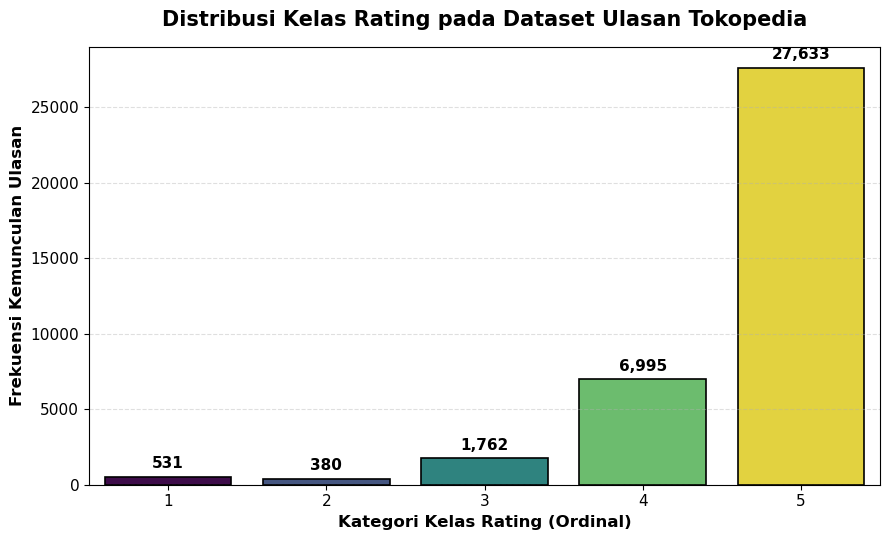


CATATAN ANALISIS SEBARAN KELAS UNTUK BAB 4:
- Kelas Mayoritas Mutlak berada pada Rating 5 dengan porsi 74.08%.
- Kelas Minoritas Mutlak berada pada Rating 2 dengan porsi 1.02%.
- Ketidakseimbangan Ekstrem: Selisih frekuensi antar kelas mencapai 72.72 kali lipat.


In [10]:
# --- 1.10 Visualisasi Distribusi Kelas (Identifikasi Class Imbalance) ---

# 1. Menghitung ringkasan statistik distribusi rating pada data sampel
dist_df = df_sample['rating'].value_counts().reset_index()
dist_df.columns = ['Rating', 'Jumlah']

# Mengunci urutan baris berdasarkan kategori tingkatan rating (1-5) secara ordinal
dist_df = dist_df.sort_values('Rating').reset_index(drop=True)
dist_df['Persentase'] = (dist_df['Jumlah'] / len(df_sample)) * 100

print("=== TABEL DISTRIBUSI RATING ORDINAL (TOTAL DATA AKURAT) ===")
display(dist_df.round(2))

# 2. Visualisasi Grafik Batang untuk memperjelas gap ekstrem antar kelas (Imbalance)
plt.figure(figsize=(9, 5.5))
ax = sns.barplot(
    x='Rating', 
    y='Jumlah', 
    data=dist_df, 
    hue='Rating', 
    palette='viridis', 
    legend=False, 
    edgecolor='black', 
    linewidth=1.2
)

# Pengaturan label dan judul grafik standar penulisan ilmiah
plt.title('Distribusi Kelas Rating pada Dataset Ulasan Tokopedia', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Kategori Kelas Rating (Ordinal)', fontsize=12, fontweight='bold')
plt.ylabel('Frekuensi Kemunculan Ulasan', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)

# Menambahkan label jumlah absolut dengan format pemisah ribuan otomatis
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=4, fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('distribution_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Narasi Otomatis Singkat
kelas_mayoritas = dist_df.loc[dist_df['Jumlah'].idxmax()]
kelas_minoritas = dist_df.loc[dist_df['Jumlah'].idxmin()]
rasio_imbalance = kelas_mayoritas['Jumlah'] / kelas_minoritas['Jumlah']

print("\n" + "=" * 75)
print("CATATAN ANALISIS SEBARAN KELAS UNTUK BAB 4:")
print("=" * 75)
print(f"- Kelas Mayoritas Mutlak berada pada Rating {int(kelas_mayoritas['Rating'])} dengan porsi {kelas_mayoritas['Persentase']:.2f}%.")
print(f"- Kelas Minoritas Mutlak berada pada Rating {int(kelas_minoritas['Rating'])} dengan porsi {kelas_minoritas['Persentase']:.2f}%.")
print(f"- Ketidakseimbangan Ekstrem: Selisih frekuensi antar kelas mencapai {rasio_imbalance:.2f} kali lipat.")
print("=" * 75)

In [11]:
# --- 1.11 Ekspor Data Sampel dan Validasi Integritas ---

# 1. Penyimpanan Data (Checkpoint)
# Menyimpan data sampel ulasan ke dalam format CSV agar hasil sampling konsisten
df_sample.to_csv('data_sample.csv', index=False)
print("Pesan: Data sampel berhasil diamankan ke 'data_sample.csv'")

# 2. Pemuatan Kembali dan Validasi Data
# Tahap ini memastikan data yang tersimpan dapat terbaca kembali dengan benar
print("Sedang memuat kembali data sampel untuk validasi...")
df_sample = pd.read_csv('data_sample.csv')

# 3. Penanganan Nilai Kosong (Handling Missing Values)
# Menghapus baris yang memiliki nilai NaN pada kolom teks atau label untuk menghindari error NLP
initial_len = len(df_sample)
df_sample = df_sample.dropna(subset=['text', 'rating'])

# Memastikan tipe data pada kolom ulasan adalah string (untuk proses tokenisasi)
df_sample['text'] = df_sample['text'].astype(str)

# 4. Ringkasan Status Kesiapan Data
if len(df_sample) != initial_len:
    print(f"Info: {initial_len - len(df_sample)} baris NaN ditemukan dan telah dibersihkan.")
else:
    print("Info: Integritas data terjaga, tidak ditemukan nilai NaN.")

print(f"Total Data Siap Masuk Tahap Preprocessing: {len(df_sample)} baris")
display(df_sample.head())

Pesan: Data sampel berhasil diamankan ke 'data_sample.csv'
Sedang memuat kembali data sampel untuk validasi...
Info: Integritas data terjaga, tidak ditemukan nilai NaN.
Total Data Siap Masuk Tahap Preprocessing: 37301 baris


,text,rating
0,Barang sesuai pesanan dan cepat sampai,5
1,Barang bagus harga murah,5
2,Paket rapi...mantap....cepat....sampe ke tujuan,5
3,ya saya puas dgn barangnya,5
4,Responya luar biasa b mantap,5


# Tahap 2: Pra-pemrosesan Data dan Rekayasa Fitur

## A. Preprocessing

### 1. Mencari Kata Slang

In [12]:
# ==============================================================================
# TAHAP 2: TEXT PREPROCESSING (PEMBERSIHAN DATA TEKS)
# ==============================================================================

# Load data file csv yang sudah bersih
try:
    df_sample = pd.read_csv('data_sample.csv')
    print(f'Data Berhasil Dimuat. Total: {len(df_sample)} baris.')
except FileExistsError:
    print("Error: File 'data_sample.csv' tidak ditemukan. Pastikan Tahap 1 sudah dijalankan.")

# --- 2.1 Identifikasi Karakteristik Kata Slang (Observasi Data) ---

# Mendefinisikan fungsi pembersihan cepat (light cleaning) untuk analisis frekuensi
def quick_clean_check(text):
    # Mengubah teks menjadi huruf kecil
    text = str(text).lower()
    # Menghapus seluruh karakter non-huruf (angka dan simbol)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Menghapus spasi berlebih
    return re.sub(r'\s+', ' ', text).strip()

# Menerapkan pembersihan ringan pada dataset sampel ulasan
print("Sedang memproses teks dan menghitung frekuensi kata...")
all_text_sample = df_sample['text'].apply(quick_clean_check)

# Menggabungkan seluruh teks menjadi satu kumpulan kata (corpus)
all_words = ' '.join(all_text_sample).split()

# Menghitung kemunculan (frekuensi) setiap kata menggunakan Counter
word_counts = Counter(all_words)

# Menyimpan 500 kata yang paling sering muncul ke dalam DataFrame analisis
df_top_500 = pd.DataFrame(word_counts.most_common(500), columns=['Kata', 'Frekuensi'])

print("--- ANALISIS TOP 500 KATA UNTUK PENYUSUNAN KAMUS SLANG ---")

# Menampilkan hasil frekuensi kata per blok (batch) untuk memudahkan peninjauan manual
# Data ini digunakan sebagai landasan dalam menentukan entri pada Kamus Slang
for i in range(0, 500, 50):
    print(f"\n>>> Peringkat {i+1} sampai {i+50} <<<")
    print(df_top_500.iloc[i : i+50])
    print("-" * 45)

Data Berhasil Dimuat. Total: 37301 baris.
Sedang memproses teks dan menghitung frekuensi kata...
--- ANALISIS TOP 500 KATA UNTUK PENYUSUNAN KAMUS SLANG ---

>>> Peringkat 1 sampai 50 <<<
           Kata  Frekuensi
0        barang      14242
1        sesuai      10483
2         cepat       8305
3           dan       7612
4         bagus       7163
5        dengan       5108
6         sudah       5023
7        sampai       4244
8    pengiriman       4235
9          baik       4110
10       terima       3843
11       respon       3643
12          gan       3501
13           di       3369
14        kasih       3071
15       produk       2892
16       seller       2805
17      pesanan       2751
18       mantap       2727
19          nya       2550
20     diterima       2485
21    deskripsi       2410
22      packing       2292
23           yg       2191
24           ok       2178
25       thanks       2140
26    barangnya       1881
27         saya       1876
28     kualitas       1748
29 

### 2. Membuat Kamus Slang (Berdasarkan Frekuensi Kata)

In [13]:
# --- 2.2 Penyusunan Kamus Normalisasi Slang (Slang Dictionary) ---

# Mendefinisikan pemetaan (mapping) dari kata informal/typo ke bentuk baku bahasa Indonesia.
# Kamus ini disusun secara manual berdasarkan hasil analisis frekuensi pada tahap sebelumnya.
slang_data = {
    'slang': [
        # 1. NEGASI ABSOLUT & KATA HUBUNG/KETERANGAN (Top Frequency Alignment)
        'ga', 'gak', 'gk', 'ngga', 'nggak', 'g', 'tdk',
        'blm', 'belom',
        'sdh', 'udah', 'dah', 'smp', 'sampe', 'smpe', 'nyampe',
        'dgn', 'dg', 'jg', 'utk', 'tp', 'tpi', 'kalo', 'klo', 'krn', 'karna',
        
        # 2. E-COMMERCE ANCHORS & LOGISTIK (Penyatuan Variansi Kata Belanja)
        'brg', 'brgnya', 'brng', 'barangnya', 'produknya', 'product', 'item',
        'paking', 'packaging', 'packingnya', 'pakingnya', 'kemasan', 'kemasannya', 'rapih',
        'seler', 'sellernya', 'tokonya', 'penjual', 'pelapak', 'penjualnya',
        'pesen', 'pesenan', 'orderan', 'dipesan', 'order',
        'rekomen', 'recomended', 'recomend', 'rekomended', 'ori',
        
        # 3. KATA SIFAT & KATA SERU (Standardisasi Typo Emosional)
        'cepet', 'cpt', 'fast',
        'baguss', 'bagusss', 'bgs', 'bgus',
        'mantab', 'mantapp', 'mantappp', 'mantul', 'mantep', 
        'ok', 'sip', 'sipp', 'yaa', 'yaaa', 'yaaaa',
        
        # 4. TRIMA KASIH JANGKAR (Pemicu Bigram "terima kasih" di TF-IDF)
        'trims', 'tq', 'tks', 'trimakasih', 'trima', 'mksh', 'thank', 'thankyou', 'makasih', 'terimakasih', 'thanks'
    ],
    'formal': [
        # 1. NEGASI ABSOLUT & KATA HUBUNG/KETERANGAN
        'tidak', 'tidak', 'tidak', 'tidak', 'tidak', 'tidak', 'tidak',
        'belum', 'belum',
        'sudah', 'sudah', 'sudah', 'sampai', 'sampai', 'sampai', 'sampai',
        'dengan', 'dengan', 'juga', 'untuk', 'tapi', 'tapi', 'kalau', 'kalau', 'karena', 'karena',
        
        # 2. E-COMMERCE ANCHORS & LOGISTIK
        'barang', 'barang', 'barang', 'barang', 'produk', 'produk', 'barang',
        'packing', 'packing', 'packing', 'packing', 'packing', 'packing', 'rapi',
        'seller', 'seller', 'toko', 'seller', 'seller', 'seller',
        'pesanan', 'pesanan', 'pesanan', 'pesanan', 'pesanan',
        'recommended', 'recommended', 'recommended', 'recommended', 'original',
        
        # 3. KATA SIFAT & KATA SERU
        'cepat', 'cepat', 'cepat',
        'bagus', 'bagus', 'bagus', 'bagus',
        'mantap', 'mantap', 'mantap', 'mantap', 'mantap',
        'oke', 'oke', 'oke', 'ya', 'ya', 'ya',
        
        # 4. TRIMA KASIH JANGKAR
        'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 
        'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih'
    ]
}

# --- 2.3 Validasi, Penyimpanan, dan Inisialisasi Dictionary ---

# Memastikan jumlah kunci (slang) dan nilai (formal) selaras untuk mencegah error indeks
if len(slang_data['slang']) != len(slang_data['formal']):
    print(f"FATAL ERROR: Ketidaksamaan jumlah entri! Slang: {len(slang_data['slang'])}, Formal: {len(slang_data['formal'])}")
else:
    # Menyimpan kamus ke CSV untuk portabilitas dan dokumentasi lampiran skripsi
    pd.DataFrame(slang_data).to_csv('kamus_slang_skripsi.csv', index=False)
    
    # Memuat kembali dan melakukan normalisasi (lowercase & strip spasi)
    df_slang_load = pd.read_csv('kamus_slang_skripsi.csv')
    df_slang_load['slang'] = df_slang_load['slang'].astype(str).str.strip().str.lower()
    df_slang_load['formal'] = df_slang_load['formal'].astype(str).str.strip().str.lower()
    
    # Filter entri slang yang mengandung spasi (untuk efisiensi token-level mapping)
    df_slang_load = df_slang_load[~df_slang_load['slang'].str.contains(r'\s+')]
    
    # Mengonversi DataFrame menjadi Python Dictionary untuk kecepatan lookup saat preprocessing
    SLANG_DICT = dict(zip(df_slang_load['slang'], df_slang_load['formal']))
    print(f"Kamus siap digunakan! Total kosakata unik: {len(SLANG_DICT)}")

# --- 2.4 Inisialisasi Kamus Slang Umum (Pembanding dari Kaggle) ---

print("Memuat Kamus Slang Umum (Kaggle) sebagai pembanding...")

# Memeriksa apakah file tersedia di direktori
if not os.path.exists('slang_indo.csv'):
    print("FATAL ERROR: File 'slang_indo.csv' tidak ditemukan di folder direktori.")
else:
    # Membaca file slang_indo.csv
    df_slang_umum = pd.read_csv('slang_indo.csv', header=None, names=['slang', 'formal'])

    # Normalisasi teks pada kamus
    df_slang_umum['slang'] = df_slang_umum['slang'].astype(str).str.strip().str.lower()
    df_slang_umum['formal'] = df_slang_umum['formal'].astype(str).str.strip().str.lower()

    # Hapus baris kosong (NaN)
    df_slang_umum = df_slang_umum.dropna()

    # Konversi DataFrame menjadi Python Dictionary
    SLANG_DICT_UMUM = dict(zip(df_slang_umum['slang'], df_slang_umum['formal']))

    print(f"Kamus Umum siap digunakan! Total kosakata unik: {len(SLANG_DICT_UMUM)}")

# --- 2.4.B: Inisialisasi Kamus Hybrid Final (Overwrite) ---
"""
Kaggle yang membersihkan bahasa gaul secara masif (1250+ kata),
Tapi kamus Kustom yang akan Menimpa/Mengkoreksi Kaggle jika ia mencoba menerjemahkan kata-kata penting E-Commerce di Dataset.
"""

SLANG_DICT_HYBRID = {**SLANG_DICT_UMUM, **SLANG_DICT}
print(f"-> Kamus Hybrid Final       : {len(SLANG_DICT_HYBRID)} kata gabungan (Frequency-Aligned).")

Kamus siap digunakan! Total kosakata unik: 85
Memuat Kamus Slang Umum (Kaggle) sebagai pembanding...
Kamus Umum siap digunakan! Total kosakata unik: 1250
-> Kamus Hybrid Final       : 1298 kata gabungan (Frequency-Aligned).


### 3. Eksekusi Preprocessing Utama

In [14]:
# ==============================================================================
# TAHAP 2:  TEXT PREPROCESSING (4 VARIAN PARALEL)
# ==============================================================================

# --- 2.5 Definisi Fungsi Preprocessing (4 Varian) ---
# Mengunci kata negasi, kontras, dan intensitas agar TIDAK DIHAPUS dari ulasan
important_keep = {
    'tidak', 'tak', 'bukan', 'jangan', 'belum', 'kurang',
    'tapi', 'cuma', 'namun', 'walau', 'meski', 'padahal', 'cuman',
    'banget', 'sangat', 'sekali', 'agak', 'lumayan', 'super', 'paling'
}

try:
    stop_words = set(stopwords.words('indonesian'))
except:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('indonesian'))

# Saring stopword bawaan NLTK
stop_words = stop_words - important_keep

# Pre-compiling Regex Patterns untuk meningkatkan kecepatan eksekusi
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
HTML_PATTERN = re.compile(r'<.*?>|&([a-z0-9]+|#[0-9]{1,6});')
NON_ALPHA_PATTERN = re.compile(r'[^a-z\s]')
WHITESPACE_PATTERN = re.compile(r'\s+')

# VARIAN 1: DENGAN NORMALISASI SLANG
def preprocessing_with_slang(text):
    """
    Varian 1: Menggunakan Kamus Kustom lo yang sudah difokuskan ke typo elongasi.
    Dilengkapi filter stopword berbasis whitelist.
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)
    
    # TAHAP NORMALISASI SLANG (AKTIF)
    words = text.split()
    # Lookup ke Kamus Kustom
    normalized_words = [SLANG_DICT.get(word, word) for word in words]

    # Filter stopword aman (menjaga kata penting & kata dengan panjang > 1)
    final_words = [word for word in normalized_words if word not in stop_words and len(word) > 1]

    text = ' '.join(final_words)
    text = WHITESPACE_PATTERN. sub(' ', text).strip()
    return text

# VARIAN 2: TANPA NORMALISASI SLANG
def preprocessing_without_slang(text):
    """
    Varian 2: Baseline teks bersih apa adanya dari netizen tanpa intervensi kamus.
    Tetap menggunakan filter stopword berbasis whitelist agar komparasi adil.
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)

    words = text.split()
    final_words = [word for word in words if word not in stop_words and len(word) > 1]
    
    text =' '.join(final_words)
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text

# VARIAN 3: DENGAN KAMUS UMUM KAGGLE
def preprocessing_kaggle_slang(text):
    """
    Varian 3: Menggunakan Kamus Publik Kaggle skala besar (1250+ kata).
    Tetap menggunakan filter stopword berbasis whitelist agar komparasi adil.
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)

    # TAHAP NORMALISASI SLANG (KAGGLE)
    words = text.split()
    # Lookup ke kamus Kaggle
    normalized_words = [SLANG_DICT_UMUM.get(word, word) for word in words]

    final_words = [word for word in normalized_words if word not in stop_words and len(word) > 1]

    text = ' '.join(final_words)

    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text

# VARIAN 4: DENGAN KAMUS HYBRID (KAGGLE + KUSTOM)
def preprocessing_hybrid_slang(text):
    """
    Varian 4: Menggunakan Kamus Hybrid (Kaggle skala besar + Overwrite Kustom Tokopedia).
    Tetap menggunakan filter stopword berbasis whitelist agar komparasi adil.
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)

    words = text.split()
    # Lookup menggunakan kamus hybrid
    normalized_words = [SLANG_DICT_HYBRID.get(word, word) for word in words]

    final_words = [word for word in normalized_words if word not in stop_words and len(word) > 1]

    text = ' '.join(final_words)
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text

print("Fungsi preprocessing (4 varian) berhasil didefinisikan.")

Fungsi preprocessing (4 varian) berhasil didefinisikan.


In [15]:
# --- 2.6 Eksekusi Preprocessing pada Dataset Sampel (3 Pipeline Paralel) ---

print("Memulai preprocessing VARIAN 1 (Dengan Normalisasi Slang)...")
df_sample['text_clean_WITH_slang'] = df_sample['text']. apply(preprocessing_with_slang)

print("Memulai preprocessing VARIAN 2 (Tanpa Normalisasi Slang)...")
df_sample['text_clean_NO_slang'] = df_sample['text'].apply(preprocessing_without_slang)

print("Memulai preprocessing VARIAN 3 (Kamus Kaggle)...")
df_sample['text_clean_KAGGLE_slang'] = df_sample['text'].apply(preprocessing_kaggle_slang)

print("Memulai preprocessing VARIAN 4 (Kamus Hybrid)...")
df_sample['text_clean_HYBRID_slang'] = df_sample['text'].apply(preprocessing_hybrid_slang)

print("Semua varian preprocessing selesai.\n")

# --- 2.7 Verifikasi Hasil Preprocessing (Komparasi Side-by-Side) ---

pd.set_option('display.max_colwidth', 120)

print("=== KOMPARASI:  WITH SLANG NORMALIZATION (KUSTOM) vs WITHOUT SLANG NORMALIZATION vs WITH SLANG NORMALIZATION (KAGGLE) vs WITH SLANG NORMALIZATION (HYBRID) ===")

# Filter sampel yang mengandung kata slang untuk validasi efektivitas mapping
cek_sample = df_sample[df_sample['text']. str.contains('brg|yg|gan|gak|udh', case=False, na=False)]. head(5)

display(cek_sample[['text', 'text_clean_WITH_slang', 'text_clean_NO_slang', 'text_clean_KAGGLE_slang', 'text_clean_HYBRID_slang']])

# --- 2.8 Audit Integritas Data Pasca-Cleaning ---

empty_with_slang = df_sample[df_sample['text_clean_WITH_slang'] == '']. shape[0]
empty_no_slang = df_sample[df_sample['text_clean_NO_slang'] == ''].shape[0]
empty_kaggle_slang = df_sample[df_sample['text_clean_KAGGLE_slang'] == ''].shape[0]
empty_hybrid_slang = df_sample[df_sample['text_clean_HYBRID_slang'] == ''].shape[0]


print(f"\nAudit Log:")
print(f"- Data kosong (WITH slang normalization): {empty_with_slang} baris")
print(f"- Data kosong (NO slang normalization)  : {empty_no_slang} baris")
print(f"- Data kosong (KAGGLE slang normalization)  : {empty_kaggle_slang} baris")
print(f"- Data kosong (HYBRID slang normalization)  : {empty_hybrid_slang} baris")

Memulai preprocessing VARIAN 1 (Dengan Normalisasi Slang)...
Memulai preprocessing VARIAN 2 (Tanpa Normalisasi Slang)...
Memulai preprocessing VARIAN 3 (Kamus Kaggle)...
Memulai preprocessing VARIAN 4 (Kamus Hybrid)...
Semua varian preprocessing selesai.

=== KOMPARASI:  WITH SLANG NORMALIZATION (KUSTOM) vs WITHOUT SLANG NORMALIZATION vs WITH SLANG NORMALIZATION (KAGGLE) vs WITH SLANG NORMALIZATION (HYBRID) ===


,text,text_clean_WITH_slang,text_clean_NO_slang,text_clean_KAGGLE_slang,text_clean_HYBRID_slang
7,Produk sesuai dengan spec di web dan respon seller sangat cepat. Thankyou.,produk sesuai spec web respon seller sangat cepat terima kasih,produk sesuai spec web respon seller sangat cepat thankyou,produk sesuai spec web respon seller sangat cepat thankyou,produk sesuai spec web respon seller sangat cepat terima kasih
8,"Respon super cepat, pengiriman cepat, Barang bagus sesuai deskripsi penjual..thx gan",respon super cepat pengiriman cepat barang bagus sesuai deskripsi seller thx gan,respon super cepat pengiriman cepat barang bagus sesuai deskripsi penjual thx gan,respon super cepat pengiriman cepat barang bagus sesuai deskripsi penjual terima kasih gan,respon super cepat pengiriman cepat barang bagus sesuai deskripsi seller terima kasih gan
11,Sayang produk yg datang di paking kurang rapi sehingga kebuka n isinya terhambur. Saran klo mengirimkan isi paku te...,sayang produk yg packing kurang rapi kebuka isinya terhambur saran mengirimkan isi paku tembak lakban dikemasan paku...,sayang produk yg paking kurang rapi kebuka isinya terhambur saran klo mengirimkan isi paku tembak lakban dikemasan p...,sayang produk paking kurang rapi kebuka isinya terhambur saran mengirimkan isi paku tembak lakban dikemasan pakunya ...,sayang produk packing kurang rapi kebuka isinya terhambur saran mengirimkan isi paku tembak lakban dikemasan pakunya...
15,josss pokok e bisa buat langganan,joss pokok langganan,joss pokok langganan,joss pokok langganan,joss pokok langganan
16,"berfungsi dengan baik, normal",berfungsi normal,berfungsi normal,berfungsi normal,berfungsi normal



Audit Log:
- Data kosong (WITH slang normalization): 152 baris
- Data kosong (NO slang normalization)  : 150 baris
- Data kosong (KAGGLE slang normalization)  : 154 baris
- Data kosong (HYBRID slang normalization)  : 154 baris


In [16]:
# --- 2.9 Pembersihan Akhir Baris Kosong (Filtering Invalid Data) ---

initial_len = len(df_sample)
print(f"Jumlah sampel awal: {initial_len}")

# Mengonversi string kosong menjadi NaN untuk kedua varian
df_sample['text_clean_WITH_slang'] = df_sample['text_clean_WITH_slang'].replace('', np.nan)
df_sample['text_clean_NO_slang'] = df_sample['text_clean_NO_slang'].replace('', np.nan)
df_sample['text_clean_KAGGLE_slang'] = df_sample['text_clean_KAGGLE_slang'].replace('', np.nan)
df_sample['text_clean_HYBRID_slang'] = df_sample['text_clean_HYBRID_slang'].replace('', np.nan)

# Menghapus baris yang kosong di SALAH SATU atau KEDUA kolom
df_sample = df_sample.dropna(subset=['text_clean_WITH_slang', 'text_clean_NO_slang', 'text_clean_KAGGLE_slang', 'text_clean_HYBRID_slang'])
df_sample = df_sample.reset_index(drop=True)

print(f"Jumlah sampel valid: {len(df_sample)}")
print(f"Data yang berhasil dibersihkan: {initial_len - len(df_sample)} baris")

Jumlah sampel awal: 37301
Jumlah sampel valid: 37146
Data yang berhasil dibersihkan: 155 baris


### 5. Tokenisasi & Stopword Removal

In [17]:
# --- 2.10 Tahap Filtering (Stopword Removal) & Tokenisasi (2 Varian Paralel) ---

# Memastikan resource NLTK tersedia di sistem
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')

# Inisialisasi daftar stopword bahasa Indonesia standar
stop_words = set(stopwords.words('indonesian'))

# Modifikasi Stopword: Mempertahankan Kata Kunci Rating 5-Kelas
important_keep = {
    'tidak', 'tak', 'bukan', 'jangan', 'belum', 'kurang',
    'tapi', 'cuma', 'namun', 'walau', 'meski', 'padahal', 'cuman',
    'banget', 'sangat', 'sekali', 'agak', 'lumayan', 'super', 'paling',
}

# Hapus kata-kata penting di atas dari daftar stopword
stop_words = stop_words - important_keep

# Penambahan Stopword Kustom (Noise murni e-commerce)
custom_stopwords = [
    'nya', 'an', 'deh', 'amp', 'ya', 'a', 'sih', 'dong', 'tuh', 
    'lah', 'pun', 'yuk', 'yang', 'dan', 'di', 'ke', 'dari', 'dg', 'rt'
]
stop_words.update(custom_stopwords)

# Proteksi ganda
stop_words = stop_words - important_keep

def remove_stopwords(text):
    """
    Melakukan tokenisasi teks dan memfilter kata-kata yang masuk dalam daftar stopword.
    """
    if not isinstance(text, str):
        return []
    
    tokens = word_tokenize(text)
    filtered_words = [w for w in tokens if w not in stop_words and len(w) > 1]
    
    return filtered_words

# --- 2.11 Eksekusi Filtering pada Dataset (3 Pipeline) ---

print(f"Memulai proses tokenisasi & filtering VARIAN 1 (WITH slang)...")
df_sample['tokens_WITH_slang'] = df_sample['text_clean_WITH_slang'].apply(lambda x: str(x).split())

print(f"Memulai proses tokenisasi & filtering VARIAN 2 (NO slang)...")
df_sample['tokens_NO_slang'] = df_sample['text_clean_NO_slang'].apply(lambda x: str(x).split())

print(f"Memulai proses tokenisasi & filtering VARIAN 3 (KAGGLE slang)...")
df_sample['tokens_KAGGLE_slang'] = df_sample['text_clean_KAGGLE_slang'].apply(lambda x: str(x).split())

print(f"Memulai proses tokenisasi & filtering VARIAN 4 (HYBRID slang)...")
df_sample['tokens_HYBRID_slang'] = df_sample['text_clean_HYBRID_slang'].apply(lambda x: str(x).split())

print(f"\nProses tokenisasi selesai.  Total Stopwords: {len(stop_words)} kata")

print("\n=== VERIFIKASI HASIL TOKENISASI & STOPWORD REMOVAL ===")
display(df_sample[['text_clean_WITH_slang', 'tokens_WITH_slang', 
                   'text_clean_NO_slang', 'tokens_NO_slang',
                   'text_clean_KAGGLE_slang', 'tokens_KAGGLE_slang',
                   'text_clean_HYBRID_slang', 'tokens_HYBRID_slang']].head(3))

Memulai proses tokenisasi & filtering VARIAN 1 (WITH slang)...
Memulai proses tokenisasi & filtering VARIAN 2 (NO slang)...
Memulai proses tokenisasi & filtering VARIAN 3 (KAGGLE slang)...
Memulai proses tokenisasi & filtering VARIAN 4 (HYBRID slang)...

Proses tokenisasi selesai.  Total Stopwords: 752 kata

=== VERIFIKASI HASIL TOKENISASI & STOPWORD REMOVAL ===


,text_clean_WITH_slang,tokens_WITH_slang,text_clean_NO_slang,tokens_NO_slang,text_clean_KAGGLE_slang,tokens_KAGGLE_slang,text_clean_HYBRID_slang,tokens_HYBRID_slang
0,barang sesuai pesanan cepat,"[barang, sesuai, pesanan, cepat]",barang sesuai pesanan cepat,"[barang, sesuai, pesanan, cepat]",barang sesuai pesanan cepat,"[barang, sesuai, pesanan, cepat]",barang sesuai pesanan cepat,"[barang, sesuai, pesanan, cepat]"
1,barang bagus harga murah,"[barang, bagus, harga, murah]",barang bagus harga murah,"[barang, bagus, harga, murah]",barang bagus harga murah,"[barang, bagus, harga, murah]",barang bagus harga murah,"[barang, bagus, harga, murah]"
2,paket rapi mantap cepat tujuan,"[paket, rapi, mantap, cepat, tujuan]",paket rapi mantap cepat sampe tujuan,"[paket, rapi, mantap, cepat, sampe, tujuan]",paket rapi mantap cepat tujuan,"[paket, rapi, mantap, cepat, tujuan]",paket rapi mantap cepat tujuan,"[paket, rapi, mantap, cepat, tujuan]"


### 6. Stemming (Sastrawi)

In [18]:
# --- 2.12 Optimasi Stemming (Dictionary-Based Stemming - 4 Varian Paralel) ---

# Inisialisasi Stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# ============================================================================
# VARIAN 1: STEMMING UNTUK DATA DENGAN NORMALISASI SLANG
# ============================================================================

print("Mengumpulkan kosakata unik dari dataset (VARIAN 1: WITH slang)...")
all_tokens_with = [word for tokens in df_sample['tokens_WITH_slang'] for word in tokens]
unique_tokens_with = list(set(all_tokens_with))
print(f"Total kosakata unik (WITH slang normalization): {len(unique_tokens_with)} kata")

print("Memulai proses Stemming VARIAN 1...")
stemmed_dict_with = {}
for i, word in enumerate(unique_tokens_with):
    stemmed_dict_with[word] = stemmer.stem(word)
    if (i + 1) % 1000 == 0:
        print(f"  Progress: {i + 1}/{len(unique_tokens_with)}")
print(f"Selesai.  Total:  {len(stemmed_dict_with)} kata")

def apply_stemming_with(tokens):
    return [stemmed_dict_with[word] for word in tokens]

print("Menerapkan hasil stemming ke dalam dataset (VARIAN 1)...")
df_sample['stemmed_list_WITH_slang'] = df_sample['tokens_WITH_slang'].apply(apply_stemming_with)

# ============================================================================
# VARIAN 2: STEMMING UNTUK DATA TANPA NORMALISASI SLANG
# ============================================================================

print("\nMengumpulkan kosakata unik dari dataset (VARIAN 2: NO slang)...")
all_tokens_no = [word for tokens in df_sample['tokens_NO_slang'] for word in tokens]
unique_tokens_no = list(set(all_tokens_no))
print(f"Total kosakata unik (NO slang normalization): {len(unique_tokens_no)} kata")

print("Memulai proses Stemming VARIAN 2...")
stemmed_dict_no = {}
for i, word in enumerate(unique_tokens_no):
    stemmed_dict_no[word] = stemmer. stem(word)
    if (i + 1) % 1000 == 0:
        print(f"  Progress: {i + 1}/{len(unique_tokens_no)}")
print(f"Selesai.  Total: {len(stemmed_dict_no)} kata")

def apply_stemming_no(tokens):
    return [stemmed_dict_no[word] for word in tokens]

print("Menerapkan hasil stemming ke dalam dataset (VARIAN 2)...")
df_sample['stemmed_list_NO_slang'] = df_sample['tokens_NO_slang'].apply(apply_stemming_no)

# ============================================================================
# VARIAN 3: STEMMING UNTUK DATA DENGAN NORMALISASI SLANG (KAGGLE)
# ============================================================================

print("Mengumpulkan kosakata unik dari dataset (VARIAN 3: KAGGLE slang)...")
all_tokens_kaggle = [word for tokens in df_sample['tokens_KAGGLE_slang'] for word in tokens]
unique_tokens_kaggle = list(set(all_tokens_kaggle))
print(f"Total kosakata unik (KAGGLE slang normalization): {len(unique_tokens_kaggle)} kata")

print("Memulai proses Stemming VARIAN 3...")
stemmed_dict_kaggle = {}
for i, word in enumerate(unique_tokens_kaggle):
    stemmed_dict_kaggle[word] = stemmer.stem(word)
    if (i + 1) % 1000 == 0:
        print(f"  Progress: {i + 1}/{len(unique_tokens_kaggle)}")
print(f"Selesai.  Total:  {len(stemmed_dict_kaggle)} kata")

def apply_stemming_kaggle(tokens):
    return [stemmed_dict_kaggle[word] for word in tokens]

print("Menerapkan hasil stemming ke dalam dataset (VARIAN 3)...")
df_sample['stemmed_list_KAGGLE_slang'] = df_sample['tokens_KAGGLE_slang'].apply(apply_stemming_kaggle)

# ============================================================================
# VARIAN 4: STEMMING UNTUK DATA DENGAN NORMALISASI SLANG (HYBRID)
# ============================================================================

print("Mengumpulkan kosakata unik dari dataset (VARIAN 1: HYBRID slang)...")
all_tokens_hybrid = [word for tokens in df_sample['tokens_HYBRID_slang'] for word in tokens]
unique_tokens_hybrid = list(set(all_tokens_hybrid))
print(f"Total kosakata unik (HYBRID slang normalization): {len(unique_tokens_hybrid)} kata")

print("Memulai proses Stemming VARIAN 4...")
stemmed_dict_hybrid = {}
for i, word in enumerate(unique_tokens_hybrid):
    stemmed_dict_hybrid[word] = stemmer.stem(word)
    if (i + 1) % 1000 == 0:
        print(f"  Progress: {i + 1}/{len(unique_tokens_hybrid)}")
print(f"Selesai.  Total:  {len(stemmed_dict_hybrid)} kata")

def apply_stemming_hybrid(tokens):
    return [stemmed_dict_hybrid[word] for word in tokens]

print("Menerapkan hasil stemming ke dalam dataset (VARIAN 4)...")
df_sample['stemmed_list_HYBRID_slang'] = df_sample['tokens_HYBRID_slang'].apply(apply_stemming_hybrid)

# --- 2.13 Finalisasi Teks (Detokenisasi - 4 Varian) ---

df_sample['text_final_WITH_slang'] = df_sample['stemmed_list_WITH_slang']. apply(lambda x: ' '.join(x))
df_sample['text_final_NO_slang'] = df_sample['stemmed_list_NO_slang']. apply(lambda x: ' '.join(x))
df_sample['text_final_KAGGLE_slang'] = df_sample['stemmed_list_KAGGLE_slang']. apply(lambda x: ' '.join(x))
df_sample['text_final_HYBRID_slang'] = df_sample['stemmed_list_HYBRID_slang']. apply(lambda x: ' '.join(x))

print("\n=== ANALISIS DAMPAK NORMALISASI SLANG TERHADAP VOCABULARY ===")
print(f"Jumlah kata unik SEBELUM stemming:")
print(f"  - WITH slang normalization: {len(unique_tokens_with):,} kata")
print(f"  - NO slang normalization  : {len(unique_tokens_no):,} kata")
print(f"  - KAGGLE slang normalization  : {len(unique_tokens_kaggle):,} kata")
print(f"  - HYBRID slang normalization  : {len(unique_tokens_hybrid):,} kata")
print(f"  - Selisih (Reduksi)       : {len(unique_tokens_no) - len(unique_tokens_with):,} kata")

print("\n=== PERBANDINGAN DATA AKHIR (READY FOR MODELING) ===")
display(df_sample[['text_clean_WITH_slang', 'text_final_WITH_slang', 
                   'text_clean_NO_slang', 'text_final_NO_slang',
                   'text_clean_KAGGLE_slang', 'text_final_KAGGLE_slang',
                   'text_clean_HYBRID_slang', 'text_final_HYBRID_slang']]. head(3))

# --- BERSIH-BERSIH MEMORI RAM VIA GC COLLECT ---
# Menghapus seluruh list token raksasa dan dictionary pembantu yang sudah di-apply ke dataframe
del all_tokens_with, all_tokens_no, all_tokens_kaggle, all_tokens_hybrid
del stemmed_dict_with, stemmed_dict_no, stemmed_dict_kaggle, stemmed_dict_hybrid
gc.collect() 
print("\nRAM Cleaned! Variabel penampung token besar berhasil dihapus dari memori.")

Mengumpulkan kosakata unik dari dataset (VARIAN 1: WITH slang)...
Total kosakata unik (WITH slang normalization): 12489 kata
Memulai proses Stemming VARIAN 1...
  Progress: 1000/12489
  Progress: 2000/12489
  Progress: 3000/12489
  Progress: 4000/12489
  Progress: 5000/12489
  Progress: 6000/12489
  Progress: 7000/12489
  Progress: 8000/12489
  Progress: 9000/12489
  Progress: 10000/12489
  Progress: 11000/12489
  Progress: 12000/12489
Selesai.  Total:  12489 kata
Menerapkan hasil stemming ke dalam dataset (VARIAN 1)...

Mengumpulkan kosakata unik dari dataset (VARIAN 2: NO slang)...
Total kosakata unik (NO slang normalization): 12569 kata
Memulai proses Stemming VARIAN 2...
  Progress: 1000/12569
  Progress: 2000/12569
  Progress: 3000/12569
  Progress: 4000/12569
  Progress: 5000/12569
  Progress: 6000/12569
  Progress: 7000/12569
  Progress: 8000/12569
  Progress: 9000/12569
  Progress: 10000/12569
  Progress: 11000/12569
  Progress: 12000/12569
Selesai.  Total: 12569 kata
Menerapka

,text_clean_WITH_slang,text_final_WITH_slang,text_clean_NO_slang,text_final_NO_slang,text_clean_KAGGLE_slang,text_final_KAGGLE_slang,text_clean_HYBRID_slang,text_final_HYBRID_slang
0,barang sesuai pesanan cepat,barang sesuai pesan cepat,barang sesuai pesanan cepat,barang sesuai pesan cepat,barang sesuai pesanan cepat,barang sesuai pesan cepat,barang sesuai pesanan cepat,barang sesuai pesan cepat
1,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah,barang bagus harga murah
2,paket rapi mantap cepat tujuan,paket rapi mantap cepat tuju,paket rapi mantap cepat sampe tujuan,paket rapi mantap cepat sampe tuju,paket rapi mantap cepat tujuan,paket rapi mantap cepat tuju,paket rapi mantap cepat tujuan,paket rapi mantap cepat tuju



RAM Cleaned! Variabel penampung token besar berhasil dihapus dari memori.


In [19]:
# --- 2.14 Finalisasi dan Penyimpanan Dataset Hasil Preprocessing (4 File Terpisah) ---

# Kolom esensial yang akan disimpan
columns_base = ['text', 'rating']

# ============================================================================
# DATASET 1: DENGAN NORMALISASI SLANG (KUSTOM)
# ============================================================================

df_with_slang = df_sample[columns_base + ['text_final_WITH_slang']].copy()
df_with_slang. rename(columns={'text_final_WITH_slang': 'text_final'}, inplace=True)

# Validasi dan pembersihan data kosong
df_with_slang = df_with_slang[df_with_slang['text_final'].str.strip() != '']
df_with_slang = df_with_slang.dropna(subset=['text_final'])
df_with_slang = df_with_slang.reset_index(drop=True)

filename_with = 'data_WITH_slang_normalization.csv'
df_with_slang.to_csv(filename_with, index=False)

print(f"Dataset WITH Slang Normalization:")
print(f"  - File: {filename_with}")
print(f"  - Dimensi: {df_with_slang.shape}")
print(f"  - Kolom: {list(df_with_slang. columns)}")

# ============================================================================
# DATASET 2: TANPA NORMALISASI SLANG
# ============================================================================

df_no_slang = df_sample[columns_base + ['text_final_NO_slang']].copy()
df_no_slang.rename(columns={'text_final_NO_slang': 'text_final'}, inplace=True)

# Validasi dan pembersihan data kosong
df_no_slang = df_no_slang[df_no_slang['text_final'].str. strip() != '']
df_no_slang = df_no_slang.dropna(subset=['text_final'])
df_no_slang = df_no_slang.reset_index(drop=True)

filename_no = 'data_NO_slang_normalization.csv'
df_no_slang.to_csv(filename_no, index=False)

print(f"\nDataset WITHOUT Slang Normalization:")
print(f"  - File: {filename_no}")
print(f"  - Dimensi:  {df_no_slang. shape}")
print(f"  - Kolom: {list(df_no_slang.columns)}")

# ============================================================================
# DATASET 3: TANPA NORMALISASI SLANG (KAGGLE)
# ============================================================================

df_kaggle_slang = df_sample[columns_base + ['text_final_KAGGLE_slang']].copy()
df_kaggle_slang.rename(columns={'text_final_KAGGLE_slang': 'text_final'}, inplace=True)

# Validasi dan pembersihan data kosong
df_kaggle_slang = df_kaggle_slang[df_kaggle_slang['text_final'].str. strip() != '']
df_kaggle_slang = df_kaggle_slang.dropna(subset=['text_final'])
df_kaggle_slang = df_kaggle_slang.reset_index(drop=True)

filename_kaggle = 'data_KAGGLE_slang_normalization.csv'
df_kaggle_slang.to_csv(filename_kaggle, index=False)

print(f"\nDataset WITH Slang normalization (Kaggle):")
print(f"  - File: {filename_kaggle}")
print(f"  - Dimensi:  {df_kaggle_slang. shape}")
print(f"  - Kolom: {list(df_kaggle_slang.columns)}")

# ============================================================================
# DATASET 4: DENGAN NORMALISASI SLANG (HYBRID)
# ============================================================================

df_hybrid_slang = df_sample[columns_base + ['text_final_HYBRID_slang']].copy()
df_hybrid_slang. rename(columns={'text_final_HYBRID_slang': 'text_final'}, inplace=True)

# Validasi dan pembersihan data kosong
df_hybrid_slang = df_hybrid_slang[df_hybrid_slang['text_final'].str.strip() != '']
df_hybrid_slang = df_hybrid_slang.dropna(subset=['text_final'])
df_hybrid_slang = df_hybrid_slang.reset_index(drop=True)

filename_hybrid = 'data_HYBRID_slang_normalization.csv'
df_hybrid_slang.to_csv(filename_hybrid, index=False)

print(f"Dataset HYBRID Slang Normalization:")
print(f"  - File: {filename_hybrid}")
print(f"  - Dimensi: {df_hybrid_slang.shape}")
print(f"  - Kolom: {list(df_hybrid_slang. columns)}")

print("\n" + "="*70)
print("STATUS:  Proses Preprocessing Selesai Secara Menyeluruh (4 Varian)")
print("="*70)
print(f"Total file tersimpan: 4")
print(f"  1. {filename_with}")
print(f"  2. {filename_no}")
print(f"  3. {filename_kaggle}")
print(f"  4. {filename_hybrid}")


Dataset WITH Slang Normalization:
  - File: data_WITH_slang_normalization.csv
  - Dimensi: (37146, 3)
  - Kolom: ['text', 'rating', 'text_final']

Dataset WITHOUT Slang Normalization:
  - File: data_NO_slang_normalization.csv
  - Dimensi:  (37146, 3)
  - Kolom: ['text', 'rating', 'text_final']

Dataset WITH Slang normalization (Kaggle):
  - File: data_KAGGLE_slang_normalization.csv
  - Dimensi:  (37146, 3)
  - Kolom: ['text', 'rating', 'text_final']
Dataset HYBRID Slang Normalization:
  - File: data_HYBRID_slang_normalization.csv
  - Dimensi: (37146, 3)
  - Kolom: ['text', 'rating', 'text_final']

STATUS:  Proses Preprocessing Selesai Secara Menyeluruh (4 Varian)
Total file tersimpan: 4
  1. data_WITH_slang_normalization.csv
  2. data_NO_slang_normalization.csv
  3. data_KAGGLE_slang_normalization.csv
  4. data_HYBRID_slang_normalization.csv


## Load Hasil Preprocessing

In [20]:
# --- 2.15 Pemuatan Dataset dan Transformasi Label (Label Encoding) ---

print("Memuat dataset hasil preprocessing...\n")

y_best_rating = df_sample['rating']

# Mendefinisikan daftar file yang akan diuji
ablation_files = {
    "Varian 1: WITH Slang (Kamus Kustom)": 'data_WITH_slang_normalization.csv',
    "Varian 2: WITHOUT Slang": 'data_NO_slang_normalization.csv',
    "Varian 3: WITH Slang (Kamus Kaggle)": 'data_KAGGLE_slang_normalization.csv',
    "Varian 4: WITH Slang (Kamus Hybrid)": 'data_HYBRID_slang_normalization.csv',
}

# Dictionary untuk menyimpan X dan y dari masing-masing varian
data_ablasi = {
    'Varian 1: WITH Slang (Kamus Kustom)': {
        'X': df_sample['text_clean_WITH_slang'],
        'y': y_best_rating
    },
    'Varian 2: WITHOUT Slang': {
        'X': df_sample['text_clean_NO_slang'],
        'y': y_best_rating
    },
    'Varian 3: WITH Slang (Kamus Kaggle)': {
        'X': df_sample['text_clean_KAGGLE_slang'],
        'y': y_best_rating
    },
    'Varian 4: WITH Slang (Kamus Hybrid)': {
        'X': df_sample['text_clean_HYBRID_slang'],
        'y': y_best_rating
    }
}

for varian, filename in ablation_files.items():
    try:
        # Load data
        df_temp = pd.read_csv(filename)

        # Validasi
        df_temp['text_final'] = df_temp['text_final'].astype(str)
        df_temp = df_temp[df_temp['text_final'].str.strip() != '']
        df_temp = df_temp.dropna(subset=['rating'])

        # Simpan X dan y ke dalam dictionary
        data_ablasi[varian] = {
            'X': df_temp['text_final'],
            'y': df_temp['rating']
        }

        print(f"{varian} berhasil dimuat. Total: {len(df_temp)} baris valid.")
    
    except FileNotFoundError:
        print(f"ERROR: File {filename} tidak ditemukan!")

print("\nSeluruh dataset siap digunakan untuk tahap K-Fold Cross Validation.")

Memuat dataset hasil preprocessing...

Varian 1: WITH Slang (Kamus Kustom) berhasil dimuat. Total: 37146 baris valid.
Varian 2: WITHOUT Slang berhasil dimuat. Total: 37146 baris valid.
Varian 3: WITH Slang (Kamus Kaggle) berhasil dimuat. Total: 37146 baris valid.
Varian 4: WITH Slang (Kamus Hybrid) berhasil dimuat. Total: 37146 baris valid.

Seluruh dataset siap digunakan untuk tahap K-Fold Cross Validation.


## B. Rekayasa Fitur

### 1. Konfigurasi Strategi Evaluasi (Stratified K-Fold Cross-Validation)
Tahap ini mendefinisikan strategi evaluasi model menggunakan Stratified K-Fold Cross-Validation dengan jumlah lipatan $k = 10$. Berbeda dengan metode Hold-out split tradisional yang memotong data secara permanen, teknik ini akan membagi keseluruhan dataset (37.000+ ulasan) menjadi 10 subset (fold) secara proporsional. 
<br>
<br>
Penggunaan karakteristik Stratified sangat krusial untuk menjaga agar rasio ketidakseimbangan distribusi ordinal pada kelas target (Rating 1 hingga 5) tetap konsisten dan adil di setiap lipatan data. Pendekatan ini memastikan seluruh data secara bergantian akan merasakan menjadi data uji (testing fold) dan data latih (training fold), sehingga menghasilkan estimasi performa model yang robust, stabil, dan terhindar dari bias pemilihan data (unbiased evaluation).

In [21]:
# --- 2.16 Inisialisasi Strategi Evaluasi (Stratified K-Fold Cross-Validation) ---

print("=== KONFIGURASI EVALUASI MODEL ===")
# 1. Menentukan Jumlah Lipatan (K-Fold)
# K=10 standar umum untuk memastikan seluruh data merasakan menjadi data uji
K_SPLITS = 10

# 2. Inisialisasi StrafifiedKFold
# - shuffle=True: Mengacak urutan data agar pola urutan dari Kaggle tidak memengaruhi model
# - stratify dipertahankan secara otomatis oleh objek ini berdasarkan label rating
skf = StratifiedKFold(n_splits=K_SPLITS, shuffle=True, random_state=42)

print(f"Strategi Evaluasi: {K_SPLITS}-Fold Cross-Validation.")
print("Status: Konfigurasi CV siap diterapkan langsung pada tahap pemodelan pipeline.")
print("-"*55)

# 3. Pengamanan Data Mentah untuk Baseline (Skenario 1)
# Karena tidak ada split, maka langsung ambil teks asli (sebelum preprocessing) dari file awal
# Ini digunakan jika ingin membandingkan performa teks mentah vs teks hasil preprocessing
try:
    df_raw_check = pd.read_csv('data_sample.csv')
    X_raw_all = df_raw_check['text'].fillna('')
    print("Status: Data mentah berhasil diamankan untuk kebutuhan Baseline Skenario 1.")
except FileNotFoundError:
    print("ERROR: 'data_sample.csv' tidak ditemukan.")

=== KONFIGURASI EVALUASI MODEL ===
Strategi Evaluasi: 10-Fold Cross-Validation.
Status: Konfigurasi CV siap diterapkan langsung pada tahap pemodelan pipeline.
-------------------------------------------------------
Status: Data mentah berhasil diamankan untuk kebutuhan Baseline Skenario 1.


=== TAHAP 1: TURNAMEN VARIAN KAMUS PREPROCESSING ===
Evaluasi murni menggunakan Unigram (1,1) TANPA SMOTE lintas 10-Fold CV

Mengevaluasi Varian 1: WITH Slang (Kamus Kustom)...
 -> Skor Rata-rata Macro F1: 0.2089 (±0.0069)
Mengevaluasi Varian 2: WITHOUT Slang...
 -> Skor Rata-rata Macro F1: 0.2097 (±0.0077)
Mengevaluasi Varian 3: WITH Slang (Kamus Kaggle)...
 -> Skor Rata-rata Macro F1: 0.2105 (±0.0094)
Mengevaluasi Varian 4: WITH Slang (Kamus Hybrid)...
 -> Skor Rata-rata Macro F1: 0.2110 (±0.0095)

=== TABEL HASIL TURNAMEN KAMUS ===


,Varian Preprocessing,Macro F1-Score (CV),Std Dev
0,Varian 1: WITH Slang (Kamus Kustom),0.208949,0.006855
1,Varian 2: WITHOUT Slang,0.209659,0.007662
2,Varian 3: WITH Slang (Kamus Kaggle),0.210515,0.009398
3,Varian 4: WITH Slang (Kamus Hybrid),0.210996,0.009503


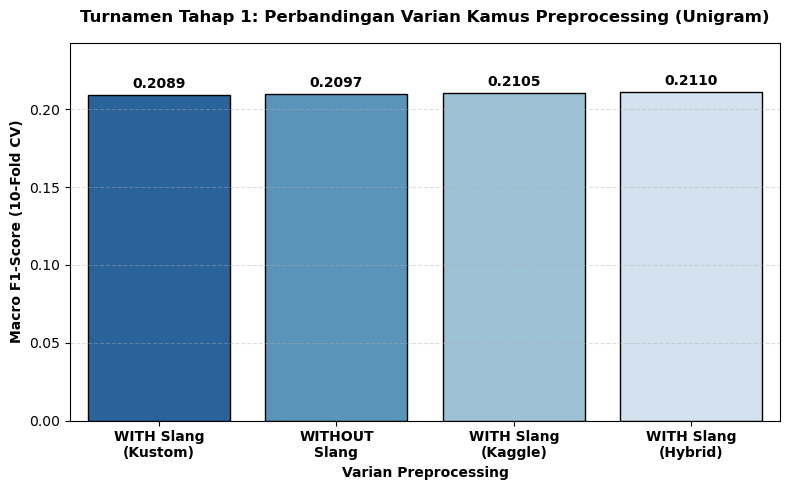


KESIMPULAN: Pemenang Kamus adalah 'Varian 4: WITH Slang (Kamus Hybrid)' dengan skor 0.2110


In [51]:
# --- 2.16.B Turnamen Varian Preprocessing ---
print("=== TAHAP 1: TURNAMEN VARIAN KAMUS PREPROCESSING ===")
print("Evaluasi murni menggunakan Unigram (1,1) TANPA SMOTE lintas 10-Fold CV\n")

vec_params = {
    'min_df': 2,
    'max_df': 0.90,
    'sublinear_tf': True,
    'strip_accents': 'unicode'
}

hasil_turnamen_kamus = []
kamus_terbaik = ""
skor_kamus_tertinggi = 0

for nama_varian, data in data_ablasi.items():
    X_data = data['X']
    y_data = data['y']
    
    # Pipeline
    pipe_kamus = ImbPipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 1), **vec_params)),
        ('clf', MultinomialNB())
    ])
    
    print(f"Mengevaluasi {nama_varian}...")
    cv_scores = cross_val_score(pipe_kamus, X_data, y_data, cv=skf, scoring='f1_macro', n_jobs=-2)
    avg_score = cv_scores.mean()
    std_score = cv_scores.std()
    
    hasil_turnamen_kamus.append({
        'Varian Preprocessing': nama_varian,
        'Macro F1-Score (CV)': avg_score,
        'Std Dev': std_score
    })
    print(f" -> Skor Rata-rata Macro F1: {avg_score:.4f} (±{std_score:.4f})")
    
    if avg_score > skor_kamus_tertinggi:
        skor_kamus_tertinggi = avg_score
        kamus_terbaik = nama_varian

# --- VISUALISASI TAHAP 1 ---
df_kamus = pd.DataFrame(hasil_turnamen_kamus)
print("\n=== TABEL HASIL TURNAMEN KAMUS ===")
display(df_kamus)

plt.figure(figsize=(8, 5))
labels_pendek_kamus = ['WITH Slang\n(Kustom)', 'WITHOUT\nSlang', 'WITH Slang\n(Kaggle)', 'WITH Slang\n(Hybrid)']
ax1 = sns.barplot(x='Varian Preprocessing', y='Macro F1-Score (CV)', data=df_kamus, palette='Blues_r', edgecolor='black', hue='Varian Preprocessing')
ax1.set_xticks(range(len(labels_pendek_kamus)))
ax1.set_xticklabels(labels_pendek_kamus, fontsize=10, fontweight='bold')

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', padding=3, fontsize=10, fontweight='bold')

plt.ylim(0, max(df_kamus['Macro F1-Score (CV)']) * 1.15)

plt.title('Turnamen Tahap 1: Perbandingan Varian Kamus Preprocessing (Unigram)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Macro F1-Score (10-Fold CV)', fontsize=10, fontweight='bold')
plt.xlabel('Varian Preprocessing', fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('turnamen_tahap1_kamus.png', dpi=300)
plt.show()

print(f"\nKESIMPULAN: Pemenang Kamus adalah '{kamus_terbaik}' dengan skor {skor_kamus_tertinggi:.4f}")


=== ANALISIS ELEMEN KOSAKATA DAN EFISIENSI DIMENSI ===
Menghitung karakteristik geometris fitur bahasa dari setiap varian preprocessing...


=== TABEL AUDIT GEOMETRIS FITUR KOSAKATA (Bahan Tabel Bab 4) ===


,Varian Preprocessing,Ukuran Vocabulary (Dimensi),Total Token Kata,Macro F1-Score (CV)
0,Varian 1: WITH Slang (Kamus Kustom),4577,239287,0.208949
1,Varian 2: WITHOUT Slang,4640,239093,0.209659
2,Varian 3: WITH Slang (Kamus Kaggle),4247,227531,0.210515
3,Varian 4: WITH Slang (Kamus Hybrid),4218,233520,0.210996


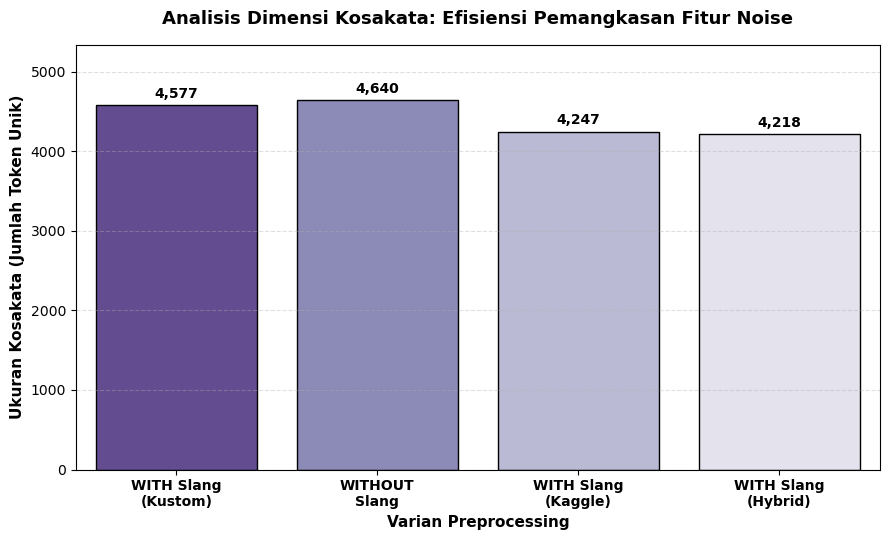


Visualisasi karakteristik kosakata sukses disimpan dengan nama: 'analisis_dimensi_kosakata_kamus.png'


In [47]:
# --- 2.16.C Analisis Karakteristik Leksikal & Efisiensi Dimensi Kosakata ---
print("\n=== ANALISIS ELEMEN KOSAKATA DAN EFISIENSI DIMENSI ===")
print("Menghitung karakteristik geometris fitur bahasa dari setiap varian preprocessing...\n")

karakteristik_kamus = []

for nama_varian, data in data_ablasi.items():
    X_data = data['X']
    
    # Inisialisasi vectorizer murni untuk mengaudit struktur fitur teks asli
    vec_audit = TfidfVectorizer(ngram_range=(1, 1), **vec_params)
    vec_audit.fit(X_data)
    
    vocab_size = len(vec_audit.get_feature_names_out())
    
    # Menghitung total kata yang tersisa di seluruh dokumen (Density check)
    total_tokens = X_data.str.split().str.len().sum()
    
    # Mengambil skor Macro F1 dari hasil turnamen sebelumnya
    skor_f1 = df_kamus[df_kamus['Varian Preprocessing'] == nama_varian]['Macro F1-Score (CV)'].values[0]
    
    karakteristik_kamus.append({
        'Varian Preprocessing': nama_varian,
        'Ukuran Vocabulary (Dimensi)': vocab_size,
        'Total Token Kata': total_tokens,
        'Macro F1-Score (CV)': skor_f1
    })

df_karakteristik = pd.DataFrame(karakteristik_kamus)
print("\n=== TABEL AUDIT GEOMETRIS FITUR KOSAKATA (Bahan Tabel Bab 4) ===")
display(df_karakteristik)

# --- VISUALISASI PERBANDINGAN DIMENSI KOSAKATA ---
plt.figure(figsize=(9, 5.5))
ax_vocab = sns.barplot(
    x='Varian Preprocessing', 
    y='Ukuran Vocabulary (Dimensi)', 
    data=df_karakteristik, 
    palette='Purples_r', 
    edgecolor='black',
    hue='Varian Preprocessing'
)
ax_vocab.set_xticks(range(len(labels_pendek_kamus)))
ax_vocab.set_xticklabels(labels_pendek_kamus, fontsize=10, fontweight='bold')

for container in ax_vocab.containers:
    ax_vocab.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10, fontweight='bold')

plt.ylim(0, max(df_karakteristik['Ukuran Vocabulary (Dimensi)']) * 1.15)
plt.title('Analisis Dimensi Kosakata: Efisiensi Pemangkasan Fitur Noise', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Ukuran Kosakata (Jumlah Token Unik)', fontsize=11, fontweight='bold')
plt.xlabel('Varian Preprocessing', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('analisis_dimensi_kosakata_kamus.png', dpi=300)
plt.show()

print("\nVisualisasi karakteristik kosakata sukses disimpan dengan nama: 'analisis_dimensi_kosakata_kamus.png'")

### 2. Feature Engineering (TF-IDF *n*-gram) &  Penanganan Imbalance (SMOTE)

=== TAHAP 2: TURNAMEN N-GRAM PADA DATA FINAL (VARIAN 4: WITH SLANG (KAMUS HYBRID)) ===
Menguji rentang token dengan integrasi SMOTE di dalam Pipeline lintas 10-Fold CV

Mengevaluasi Skenario Fitur: Unigram (1,1)...
 -> Rata-rata Macro F1: 0.3017 (±0.0061)
Mengevaluasi Skenario Fitur: Unigram + Bigram (1,2)...
 -> Rata-rata Macro F1: 0.3367 (±0.0087)
Mengevaluasi Skenario Fitur: Unigram + Bigram + Trigram (1,3)...
 -> Rata-rata Macro F1: 0.3361 (±0.0091)

=== TABEL HASIL TURNAMEN N-GRAM ===


,Skenario N-Gram,Macro F1-Score (CV),Std Dev
0,"Unigram (1,1)",0.301694,0.006132
1,"Unigram + Bigram (1,2)",0.336713,0.008712
2,"Unigram + Bigram + Trigram (1,3)",0.336054,0.009110


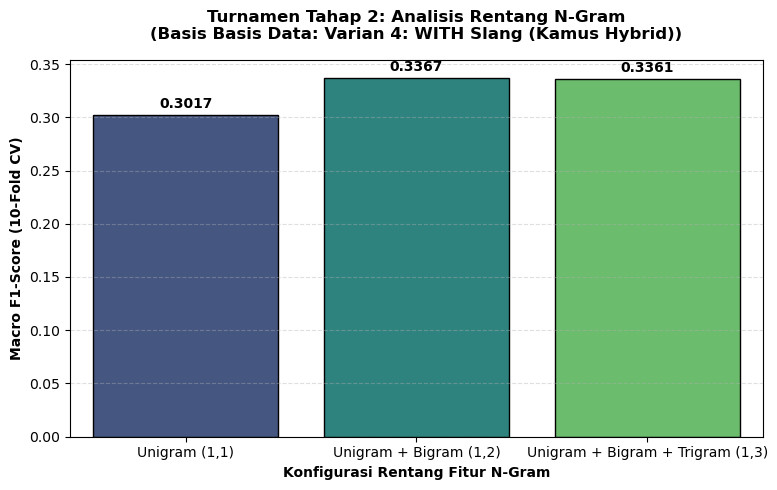


KONFIGURASI FITUR TERBAIK: Unigram + Bigram (1,2) dengan Skor 0.3367


In [48]:
# --- 2.17 Eksperimen Optimalisasi N-Gram (Khusus Varian Preprocessing Terbaik) ---
print(f"=== TAHAP 2: TURNAMEN N-GRAM PADA DATA FINAL ({kamus_terbaik.upper()}) ===")
print("Menguji rentang token dengan integrasi SMOTE di dalam Pipeline lintas 10-Fold CV\n")

X_best_kamus = data_ablasi[kamus_terbaik]['X']
y_best_kamus = data_ablasi[kamus_terbaik]['y']

ngram_scenarios = {
    'Unigram (1,1)': (1, 1),
    'Unigram + Bigram (1,2)': (1, 2),
    'Unigram + Bigram + Trigram (1,3)': (1, 3)
}

hasil_turnamen_ngram = []
highest_macro_f1 = 0
best_ngram_name = ""

for name_ngram, ngram in ngram_scenarios.items():
    print(f"Mengevaluasi Skenario Fitur: {name_ngram}...")
    
    # SMOTE diaktifkan di sini untuk melihat efek penyeimbangan pada N-gram
    pipe_ngram = ImbPipeline([
        ('tfidf', TfidfVectorizer(ngram_range=ngram, **vec_params)),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('clf', MultinomialNB())
    ])

    cv_scores = cross_val_score(pipe_ngram, X_best_kamus, y_best_kamus, cv=skf, scoring='f1_macro', n_jobs=-2)
    avg_score = cv_scores.mean()
    std_score = cv_scores.std()

    hasil_turnamen_ngram.append({
        'Skenario N-Gram': name_ngram,
        'Macro F1-Score (CV)': avg_score,
        'Std Dev': std_score
    })
    print(f" -> Rata-rata Macro F1: {avg_score:.4f} (±{std_score:.4f})")

    if avg_score > highest_macro_f1:
        highest_macro_f1 = avg_score
        best_ngram_name = name_ngram
        best_global_config = {
            'varian': kamus_terbaik,
            'ngram_name': name_ngram,
            'ngram_range': ngram,
            'k_neighbors': 3
        }

# --- VISUALISASI TAHAP 2: TURNAMEN N-GRAM ---
df_ngram_results = pd.DataFrame(hasil_turnamen_ngram)
print("\n=== TABEL HASIL TURNAMEN N-GRAM ===")
display(df_ngram_results)

plt.figure(figsize=(8, 5))
ax2 = sns.barplot(x='Skenario N-Gram', y='Macro F1-Score (CV)', data=df_ngram_results, palette='viridis', edgecolor='black', hue='Skenario N-Gram')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', padding=3, fontsize=10, fontweight='bold')


plt.title(f'Turnamen Tahap 2: Analisis Rentang N-Gram\n(Basis Basis Data: {kamus_terbaik})', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Macro F1-Score (10-Fold CV)', fontsize=10, fontweight='bold')
plt.xlabel('Konfigurasi Rentang Fitur N-Gram', fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('turnamen_tahap2_ngram.png', dpi=300)
plt.show()

print(f"\nKONFIGURASI FITUR TERBAIK: {best_ngram_name} dengan Skor {highest_macro_f1:.4f}")

### Cek Penanganan Imbalance (SMOTE)

In [29]:
# --- 2.19 Ekstraksi dan Verifikasi Data Final (Post-SMOTE & N-Gram Terbaik) ---

print("=== VERIFIKASI DIMENSI & KARAKTERISTIK DATASET OPTIMAL ===")

# 1. Mengambil data dari varian preprocessing terbaik hasil 
best_variant_name = best_global_config['varian']
X_best_text = data_ablasi[best_variant_name]['X']
y_best_rating = data_ablasi[best_variant_name]['y']

# 2. Inisialisasi Vecrotizer dengan N-gram Terbaik hasil
final_vec = TfidfVectorizer(ngram_range=best_global_config['ngram_range'], **vec_params)

# 3. Transformasi Teks menjadi Matriks TF-IDF (Sparse CSR Matrix - Efisien RAM)
X_final_tfidf = final_vec.fit_transform(X_best_text)

# 4. Aplikasi SMOTE Secara Eksplisit Menggunakan k_neighbors yg aman
sm_final = SMOTE(random_state=42, k_neighbors=best_global_config['k_neighbors'])
X_resampled_check, y_resampled_check = sm_final.fit_resample(X_final_tfidf, y_best_rating)

# 5. Output Informasi untuk Lampiran dan Bab 4 Skripsi
print(f"Varian Preprocessing Terpilih       : {best_variant_name}")
print(f"Kombinasi N-gram Terpilih           : {best_global_config['ngram_name']} {best_global_config['ngram_range']}")
print(f"Jumlah Fitur Bahasa (Vocabulary)    : {len(final_vec.get_feature_names_out()):,} dimensi")
print(f"Tipe Representasi Data X            : {X_resampled_check.shape[0]:,} baris (Native Sparse CSR)")
print("-"*60)

# Menghitung distribusi kelas rating setelah diseimbangkan oleh SMOTE
dist_final = Counter(y_resampled_check)
print("Distribusi Kelas Pasca_SMOTE (Semua Target Rating Menjadi Seimbang):")
for rating_label in sorted(dist_final.keys()):
    print(f" - Rating {rating_label} : {dist_final[rating_label]:,} sampel")

print("-"*60)
X_best_text = data_ablasi[best_variant_name]['X']
print(f"Dimensi Akhir Matriks Fitur X: {X_resampled_check.shape}")
print(f"Status: Verifikasi integritas data selesai. Struktur siap diteruskan ke GridSearch.")

=== VERIFIKASI DIMENSI & KARAKTERISTIK DATASET OPTIMAL ===
Varian Preprocessing Terpilih       : Varian 4: WITH Slang (Kamus Hybrid)
Kombinasi N-gram Terpilih           : Unigram + Bigram (1,2) (1, 2)
Jumlah Fitur Bahasa (Vocabulary)    : 16,701 dimensi
Tipe Representasi Data X            : 137,650 baris (Native Sparse CSR)
------------------------------------------------------------
Distribusi Kelas Pasca_SMOTE (Semua Target Rating Menjadi Seimbang):
 - Rating 1 : 27,530 sampel
 - Rating 2 : 27,530 sampel
 - Rating 3 : 27,530 sampel
 - Rating 4 : 27,530 sampel
 - Rating 5 : 27,530 sampel
------------------------------------------------------------
Dimensi Akhir Matriks Fitur X: (137650, 16701)
Status: Verifikasi integritas data selesai. Struktur siap diteruskan ke GridSearch.


=== GENERASI GRAPH KOMPARASI PENYEIMBANGAN KELAS (SMOTE) ===


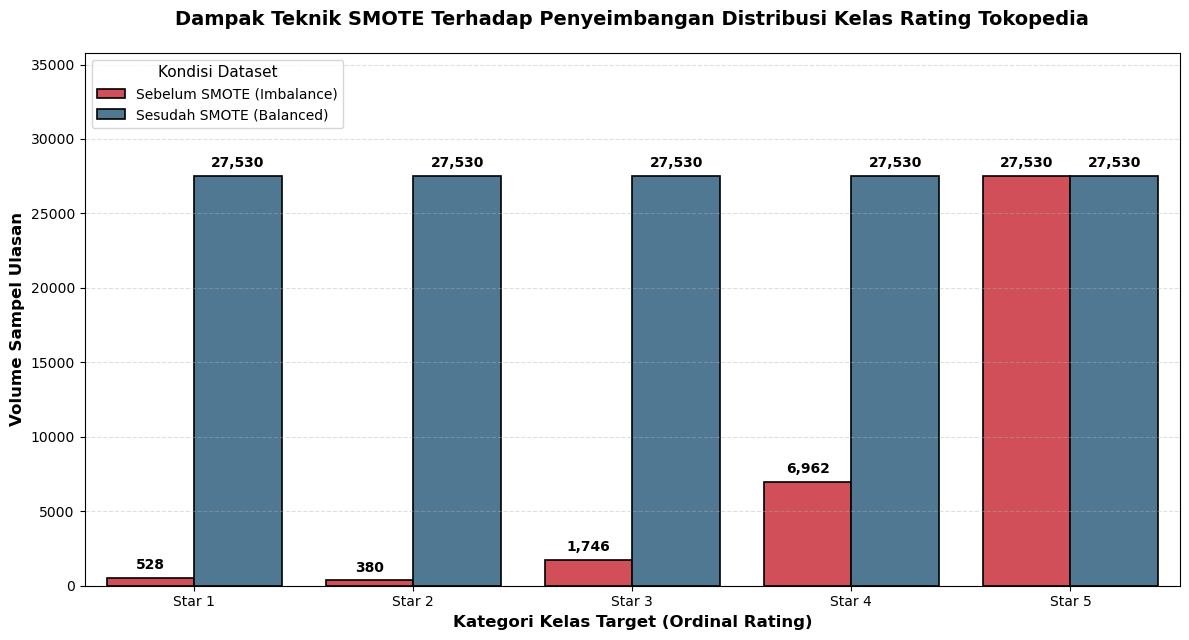


Visualisasi dampak SMOTE sukses disimpan dengan nama: 'dampak_smote_balancing_comparison.png'
Total Baris Dataset Sebelum SMOTE : 37,146 baris
Total Baris Dataset Sesudah SMOTE : 137,650 baris (Pertumbuhan Volume: 270.56%)


In [30]:
# --- 2.19.2 Visualisasi Komparasi Distribusi Kelas: Sebelum vs Sesudah SMOTE ---

print("=== GENERASI GRAPH KOMPARASI PENYEIMBANGAN KELAS (SMOTE) ===")

# 1. Mengambil data distribusi sebelum SMOTE
dist_sebelum = y_best_rating.value_counts().sort_index()

# 2. Mengambil data distribusi sesudah SMOTE (dari variabel y_resampled_check di Sel 2.19)
dist_sesudah = pd.Series(y_resampled_check).value_counts().sort_index()

# 3. Rekonstruksi menjadi DataFrame untuk kebutuhan plotting Seaborn
df_compare_smote = pd.DataFrame({
    'Rating': [f'Star {i}' for i in dist_sebelum.index] * 2,
    'Jumlah Sampel': list(dist_sebelum.values) + list(dist_sesudah.values),
    'Kondisi Dataset': ['Sebelum SMOTE (Imbalance)'] * 5 + ['Sesudah SMOTE (Balanced)'] * 5
})

# 4. Inisialisasi Plotting Berdampingan
plt.figure(figsize=(12, 6.5))
ax = sns.barplot(
    x='Rating',
    y='Jumlah Sampel',
    hue='Kondisi Dataset',
    data=df_compare_smote,
    palette=['#e63946', '#457b9d'],
    edgecolor='black',
    linewidth=1.2
)

# 5. Menambahkan Label Angka di Atas Setiap Batang Grafik
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=4, fontsize=10, fontweight='bold')

# 6. Styling Estetika Grafik Karya Ilmiah
plt.title('Dampak Teknik SMOTE Terhadap Penyeimbangan Distribusi Kelas Rating Tokopedia', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Kategori Kelas Target (Ordinal Rating)', fontsize=12, fontweight='bold')
plt.ylabel('Volume Sampel Ulasan', fontsize=12, fontweight='bold')
plt.ylim(0, max(dist_sesudah.values) * 1.30)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Kondisi Dataset", loc='upper left', fontsize=10, title_fontsize=11)
plt.tight_layout()

# Simpan gambar kualitas cetak
plt.savefig('dampak_smote_balancing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi dampak SMOTE sukses disimpan dengan nama: 'dampak_smote_balancing_comparison.png'")
print(f"Total Baris Dataset Sebelum SMOTE : {len(y_best_rating):,} baris")
print(f"Total Baris Dataset Sesudah SMOTE : {len(y_resampled_check):,} baris (Pertumbuhan Volume: {((len(y_resampled_check)-len(y_best_rating))/len(y_best_rating))*100:.2f}%)")

# Tahap 3: Hyperparameter Tuning

=== TAHAP 3: TUNING PIPELINE (INTEGRATED OPTIMIZATION) ===
Menggunakan Dataset Optimal: Varian 4: WITH Slang (Kamus Hybrid)
Konfigurasi Fitur          : N-gram (1, 2)
Total kombinasi parameter yang akan diuji: 34 kombinasi.
Sedang mencari kombinasi parameter optimal melalui iterasi sistematis lintas rentang luas...
Fitting 10 folds for each of 34 candidates, totalling 340 fits



HASIL OPTIMASI HYPERPARAMETER GLOBAL (FINAL)
Optimal SMOTE k_neighbors : 3
Optimal Alpha Smoothing   : 0.1
Optimal Fit Prior         : True
Skor Validasi (Macro F1)  : 0.3437


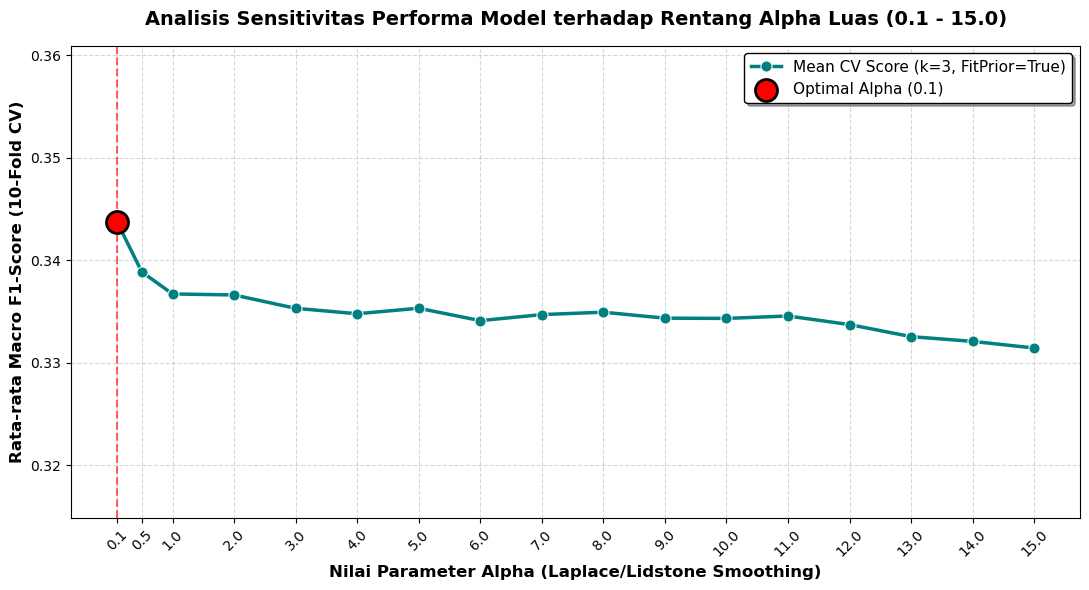


Grafik sensitivitas sukses disimpan dengan nama: 'sensitivitas_alpha_hyperparameter.png'


13301

In [31]:
# ==============================================================================
# TAHAP 3: OPTIMASI MODEL (HYPERPARAMETER TUNING)
# ==============================================================================

# Tahap ini bertujuan untuk mencari parameter terbaik bagi algoritma SMOTE dan 
# Multinomial Naive Bayes guna meminimalisir bias dan memaksimalkan generalisasi model.

print("=== TAHAP 3: TUNING PIPELINE (INTEGRATED OPTIMIZATION) ===")
best_variant_name = best_global_config['varian']
best_ngram_range = best_global_config['ngram_range']
best_k_neighbors = best_global_config['k_neighbors']

X_best_text = data_ablasi[best_variant_name]['X']
y_best_rating = data_ablasi[best_variant_name]['y']

print(f"Menggunakan Dataset Optimal: {best_variant_name}")
print(f"Konfigurasi Fitur          : N-gram {best_ngram_range}")

# 1. Konstruksi Pipeline Optimasi
# Pipeline dibangun untuk menjamin isolasi data pada setiap iterasi Cross-Validation.
pipeline_tuning = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=best_ngram_range, **vec_params)),
    ('smote', SMOTE(random_state=42)), 
    ('clf', MultinomialNB())
])

# 2. Definisi Ruang Parameter (Parameter Grid)
# Menguji variasi k-neighbors untuk SMOTE dan nilai Smoothing Alpha untuk Naive Bayes.
# - clf__alpha: Diperluas dari 1.0 sampai 15.0 dengan kombinasi nilai halus dan standar ilmiah
# - smote__k_neighbors: Disesuaikan secara dinamis agar tidak melebihi batas ukuran kelas terkecil
k_neighbors_options = [3, 5, 7]
k_neighbors_options = [k for k in k_neighbors_options if k <= best_k_neighbors]
param_grid = {
    'smote__k_neighbors': k_neighbors_options,      # Optimasi struktur sintetis data minoritas
    'clf__alpha': [ 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0], # Optimasi Laplace/Lidstone Smoothing
    'clf__fit_prior': [True, False]       # Optimasi pengaruh probabilitas kelas awal
}

print(f"Total kombinasi parameter yang akan diuji: {len(param_grid['smote__k_neighbors']) * len(param_grid['clf__alpha']) * len(param_grid['clf__fit_prior'])} kombinasi.")

# 3. Inisialisasi Grid Search dengan 10-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=pipeline_tuning,
    param_grid=param_grid,
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-2, 
    verbose=1
)

# 4. Pelatihan Model Tuning (Fit pada Varian Data Terbaik)
print("Sedang mencari kombinasi parameter optimal melalui iterasi sistematis lintas rentang luas...")
grid_search.fit(X_best_text, y_best_rating)

# 5. Ekstraksi Konfigurasi Terbaik
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n" + "="*60)
print("HASIL OPTIMASI HYPERPARAMETER GLOBAL (FINAL)")
print("="*60)
print(f"Optimal SMOTE k_neighbors : {best_params['smote__k_neighbors']}")
print(f"Optimal Alpha Smoothing   : {best_params['clf__alpha']}")
print(f"Optimal Fit Prior         : {best_params['clf__fit_prior']}")
print(f"Skor Validasi (Macro F1)  : {best_score:.4f}")

# Menyimpan pipeline model terbaik untuk tahap evaluasi akhir
best_model_pipeline = grid_search.best_estimator_

# --- 3.1 Visualisasi Analisis Sensitivitas Parameter ---
results_df = pd.DataFrame(grid_search.cv_results_)
best_k = best_params['smote__k_neighbors']
best_prior = best_params['clf__fit_prior']

# Filter data untuk visualisasi berdasarkan kombinasi k_neighbors dan fit_prior terbaik
filtered_df = results_df[
    (results_df['param_smote__k_neighbors'] == best_k) & (results_df['param_clf__fit_prior'] == best_prior)
].copy()
filtered_df['param_clf__alpha'] = filtered_df['param_clf__alpha'].astype(float)
filtered_df = filtered_df.sort_values(by='param_clf__alpha')

plt.figure(figsize=(11, 6))

# Plot kurva sensitivitas parameter alpha
sns.lineplot(data=filtered_df, x='param_clf__alpha', y='mean_test_score', 
             marker='o', color='teal', linewidth=2.5, markersize=8, 
             label=f'Mean CV Score (k={best_k}, FitPrior={best_prior})')

# Plot titik merah penanda lokasi koordinat nilai optimal (Best Estimator)
plt.scatter(best_params['clf__alpha'], best_score, 
            color='red', s=250, zorder=5, edgecolor='black', linewidth=2,  
            label=f"Optimal Alpha ({best_params['clf__alpha']})")

plt.axvline(x=best_params['clf__alpha'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)

plt.title('Analisis Sensitivitas Performa Model terhadap Rentang Alpha Luas (0.1 - 15.0)', 
          fontsize=14, fontweight='bold', pad=15)  

plt.xlabel('Nilai Parameter Alpha (Laplace/Lidstone Smoothing)', fontsize=12, fontweight='bold') 
plt.ylabel('Rata-rata Macro F1-Score (10-Fold CV)', fontsize=12, fontweight='bold') 

plt.ylim(min(filtered_df['mean_test_score']) * 0.95, best_score * 1.05)
plt.xticks(param_grid['clf__alpha'], rotation=45) # Dimiringkan

plt.tick_params(axis='both', labelsize=10) 
plt.legend(fontsize=11, loc='best', frameon=True, shadow=True, edgecolor='black') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save
plt.savefig('sensitivitas_alpha_hyperparameter.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGrafik sensitivitas sukses disimpan dengan nama: 'sensitivitas_alpha_hyperparameter.png'")
import gc
gc.collect()

# Tahap 4: Evaluasi Final & Komparasi Skenario

=== MEMULAI ANALISIS MULTI-SKENARIO (TOTAL 5 PENGUJIAN FULL 10-FOLD CV) ===

[1/5] Running Skenario 1: Baseline (Kondisi Awal Teks Mentah)...

[2/5] Running Skenario 2: Integrasi Preprocessing (Varian 4: WITH Slang (Kamus Hybrid))...

[3/5] Running Skenario 3: Integrasi N-Gram Unigram + Bigram (1,2)...

[4/5] Running Skenario 4: Integrasi SMOTE Resampling...

[5/5] Mengambil hasil Skenario 5: Integrasi Hyperparameter Tuning...

HASIL KOMPARASI AKHIR PENELITIAN


,Skenario,Macro F1 (CV),Std Dev
0,1. Baseline (Raw),0.170439,0.000386
1,2. Preprocessing,0.210996,0.009503
2,3. Fitur N-Gram,0.200775,0.003485
3,4. SMOTE Resampling,0.336713,0.008712
4,5. Final Tuning,0.343730,0.009335


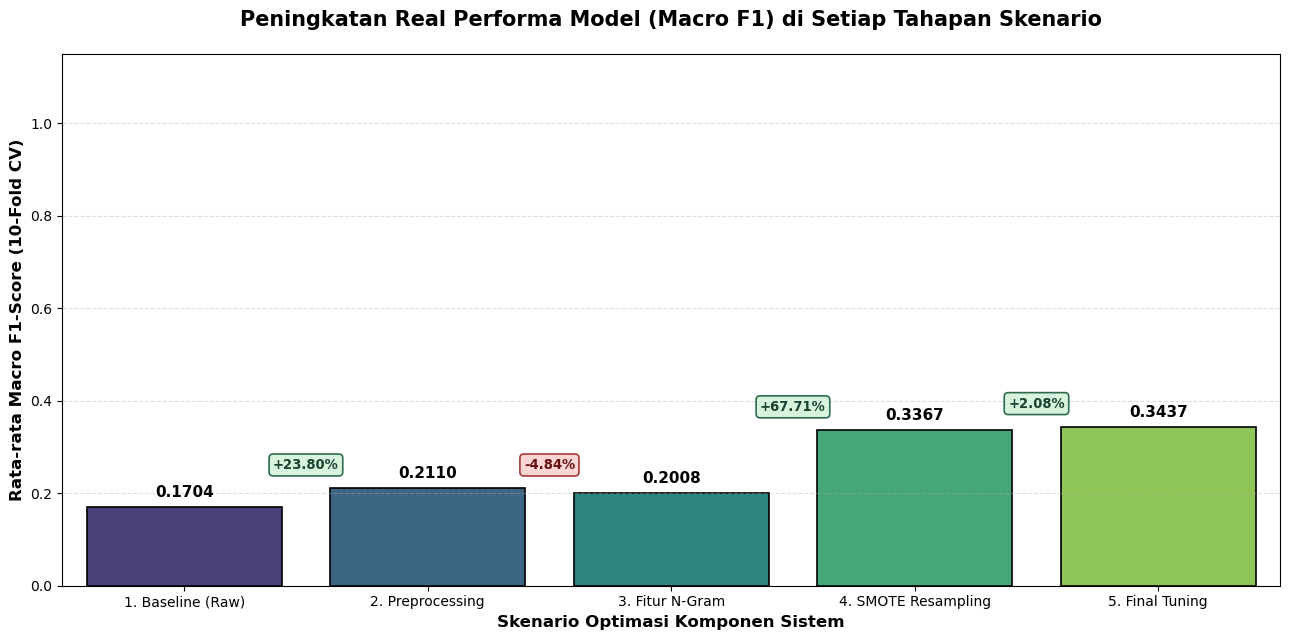

In [32]:
# ==============================================================================
# TAHAP 4: EVALUASI KOMPARATIF (ABLATION STUDY - 5 SKENARIO FINAL)
# ==============================================================================

# Tahap ini bertujuan untuk mengukur kontribusi setiap komponen sistem terhadap
# peningkatan performa model secara keseluruhan dari Baseline hingga Final Tuning.

# Mengambil basis data varian terbaik hasil otomatis turnamen N-Gram
best_variant_name = best_global_config['varian']
X_best_text = data_ablasi[best_variant_name]['X']
y_best_rating = data_ablasi[best_variant_name]['y']

komparasi_results = []

print("=== MEMULAI ANALISIS MULTI-SKENARIO (TOTAL 5 PENGUJIAN FULL 10-FOLD CV) ===")

# --- SKENARIO 1: BASELINE MODEL ---
# Menggunakan data mentah (raw), Unigram, tanpa penyeimbangan kelas, dan parameter default.
print("\n[1/5] Running Skenario 1: Baseline (Kondisi Awal Teks Mentah)...")

# Sinkronisasi indeks data mentah
X_raw_synchronized = X_raw_all.loc[y_best_rating.index]

pipe_1 = ImbPipeline([
    ('tfidf', TfidfVectorizer(tokenizer=lambda x: str(x).split(), token_pattern=None, lowercase=False)),
    ('clf', MultinomialNB()) # Alpha default = 1.0, fit_prior = True
])
cv_scores_1 = cross_val_score(pipe_1, X_raw_synchronized, y_best_rating, cv=skf, scoring='f1_macro', n_jobs=-2)

komparasi_results.append({
    'Skenario': '1. Baseline (Raw)',
    'Macro F1 (CV)': cv_scores_1.mean(),
    'Std Dev': cv_scores_1.std()
})

# --- SKENARIO 2: IMPACT OF PREPROCESSING ---
# Menambahkan tahap Normalisasi Slang dan Stemming (Unigram + Default NB).
print(f"\n[2/5] Running Skenario 2: Integrasi Preprocessing ({best_variant_name})...")
pipe_2 = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1), **vec_params)),
    ('clf', MultinomialNB())
])
cv_scores_2 = cross_val_score(pipe_2, X_best_text, y_best_rating, cv=skf, scoring='f1_macro', n_jobs=-2)

komparasi_results.append({
    'Skenario': '2. Preprocessing',
    'Macro F1 (CV)': cv_scores_2.mean(),
    'Std Dev': cv_scores_2.std()
})

# --- SKENARIO 3: IMPACT OF N-GRAM FEATURES ---
# Menggunakan rentang N-Gram optimal hasil turnamen (Tanpa SMOTE).
print(f"\n[3/5] Running Skenario 3: Integrasi N-Gram {best_global_config['ngram_name']}...")
pipe_3 = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=best_global_config['ngram_range'], **vec_params)),
    ('clf', MultinomialNB())
])
cv_scores_3 = cross_val_score(pipe_3, X_best_text, y_best_rating, cv=skf, scoring='f1_macro', n_jobs=-2)

komparasi_results.append({
    'Skenario': '3. Fitur N-Gram',
    'Macro F1 (CV)': cv_scores_3.mean(),
    'Std Dev': cv_scores_3.std()
})

# --- SKENARIO 4: IMPACT OF CLASS RESAMPLING ---
# Menangani Imbalance Data menggunakan SMOTE dengan konfigurasi tetangga dinamis.
print("\n[4/5] Running Skenario 4: Integrasi SMOTE Resampling...")
pipe_4 = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=best_global_config['ngram_range'], **vec_params)),
    ('smote', SMOTE(random_state=42, k_neighbors=best_global_config['k_neighbors'])),
    ('clf', MultinomialNB())
])
cv_scores_4 = cross_val_score(pipe_4, X_best_text, y_best_rating, cv=skf, scoring='f1_macro', n_jobs=-2)

komparasi_results.append({
    'Skenario': '4. SMOTE Resampling',
    'Macro F1 (CV)': cv_scores_4.mean(),
    'Std Dev': cv_scores_4.std()
})

# --- SKENARIO 5: OPTIMASI FINAL (HYPERPARAMETER TUNING) ---
# Dioptimalkan via Gemini Pro Review: Mengambil langsung hasil terbaik dari GridSearchCV 
# tanpa membuang waktu komputasi running ulang 10-Fold CV yang redundan.
print(f"\n[5/5] Mengambil hasil Skenario 5: Integrasi Hyperparameter Tuning...")
best_cv_score = grid_search.best_score_
best_cv_std = grid_search.cv_results_['std_test_score'][grid_search.best_index_]

komparasi_results.append({
    'Skenario': '5. Final Tuning',
    'Macro F1 (CV)': best_cv_score,
    'Std Dev': best_cv_std
})

# --- 4.1 Visualisasi Komparasi Performa Keseluruhan ---
print("\n" + "="*65)
print("HASIL KOMPARASI AKHIR PENELITIAN")
print("="*65)
df_komparasi = pd.DataFrame(komparasi_results)
display(df_komparasi)

plt.figure(figsize=(13, 6.5))
ax = sns.barplot(x='Skenario', y='Macro F1 (CV)', data=df_komparasi, 
                 palette='viridis', hue='Skenario', legend=False,
                 edgecolor='black', linewidth=1.2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=11, fontweight='bold')

# PERHITUNGAN DAN PENEMPELAN BADGE MARGINAL PERSENTASE KENAIKAN ANTAR TAHAP
for i in range(1, len(df_komparasi)):
    prev_val = df_komparasi.iloc[i-1]['Macro F1 (CV)']
    curr_val = df_komparasi.iloc[i]['Macro F1 (CV)']
    change = ((curr_val - prev_val) / prev_val) * 100
    
    if abs(change) > 0.001:
        color = '#1b4332' if change > 0 else '#641111'
        face_color = '#d8f3dc' if change > 0 else '#fcd5d5'
        edge_color = '#2d6a4f' if change > 0 else '#a63a3a'
        sign = '+' if change > 0 else ''
        
        # Mengatur posisi badge secara simetris di tengah-tengah antar balok batang
        x_pos = (i - 1 + i) / 2
        y_pos = max(prev_val, curr_val) + 0.05
        
        ax.text(x_pos, y_pos, f'{sign}{change:.2f}%',
                ha='center', va='center', fontsize=9.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=face_color, 
                         edgecolor=edge_color, linewidth=1.2))

plt.title('Peningkatan Real Performa Model (Macro F1) di Setiap Tahapan Skenario', 
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Rata-rata Macro F1-Score (10-Fold CV)', fontsize=12, fontweight='bold')
plt.xlabel('Skenario Optimasi Komponen Sistem', fontsize=12, fontweight='bold')
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ablation_study_5_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# --- 2.20 Analisis Ukuran Kosakata (Vocabulary Size) Lintas Skenario ---
print("=== ANALISIS TRANSFORMASI DIMENSI FITUR TEKSTUAL ===")

# PERBAIKAN: Ambil dari df_ngram_results (kodingan Sel 2.17 baru lo)
# Kita cari baris yang menggunakan konfigurasi terbaik hasil turnamen
nama_ngram_terbaik = best_global_config['ngram_name']
df_optimal_ngram = df_ngram_results[df_ngram_results['Skenario N-Gram'] == nama_ngram_terbaik].copy()

# 2. Inisialisasi ulang Vectorizer Baseline vs Optimal untuk hitung dimensi kosakata asli
vec_baseline = TfidfVectorizer(tokenizer=lambda x: str(x).split(), token_pattern=None, lowercase=False)
vec_baseline.fit(X_raw_synchronized)

vec_optimal = TfidfVectorizer(ngram_range=best_global_config['ngram_range'], **vec_params)
vec_optimal.fit(X_best_text)

print(f"Kombinasi N-Gram Terpilih           : {nama_ngram_terbaik}")
print(f"Ukuran Kosakata Skenario Baseline   : {len(vec_baseline.get_feature_names_out()):,} fitur")
print(f"Ukuran Kosakata Skenario Teroptimasi: {len(vec_optimal.get_feature_names_out()):,} fitur")

# Hitung rasio efisiensi dimensi teks
pangkas_fitur = len(vec_baseline.get_feature_names_out()) - len(vec_optimal.get_feature_names_out())
persen_pangkas = (pangkas_fitur / len(vec_baseline.get_feature_names_out())) * 100
print(f"Efisiensi Kompresi Dimensi Kosakata : Dipangkas {pangkas_fitur:,} fitur ({persen_pangkas:.2f}%)")

=== ANALISIS TRANSFORMASI DIMENSI FITUR TEKSTUAL ===
Kombinasi N-Gram Terpilih           : Unigram + Bigram (1,2)
Ukuran Kosakata Skenario Baseline   : 35,158 fitur
Ukuran Kosakata Skenario Teroptimasi: 16,701 fitur
Efisiensi Kompresi Dimensi Kosakata : Dipangkas 18,457 fitur (52.50%)


=== TABEL HASIL EKSPERIMEN N-GRAM ===


,Skenario N-Gram,Ukuran Vocabulary,Macro F1-Score (CV),Std Dev
0,"Unigram (1,1)",4218,0.301694,0.006132
1,"Unigram + Bigram (1,2)",16701,0.336713,0.008712
2,"Unigram + Bigram + Trigram (1,3)",27864,0.336054,0.009110



ANALISIS GEOMETRIS PENINGKATAN FITUR LINGUISTIK
Konfigurasi N-Gram Optimal   : Unigram + Bigram (1,2)
Ledakan Dimensi Fitur        : +12,483 kata baru (+295.95%)
Kenaikan Nilai Riil Macro F1 : +0.0350 (+11.61%)


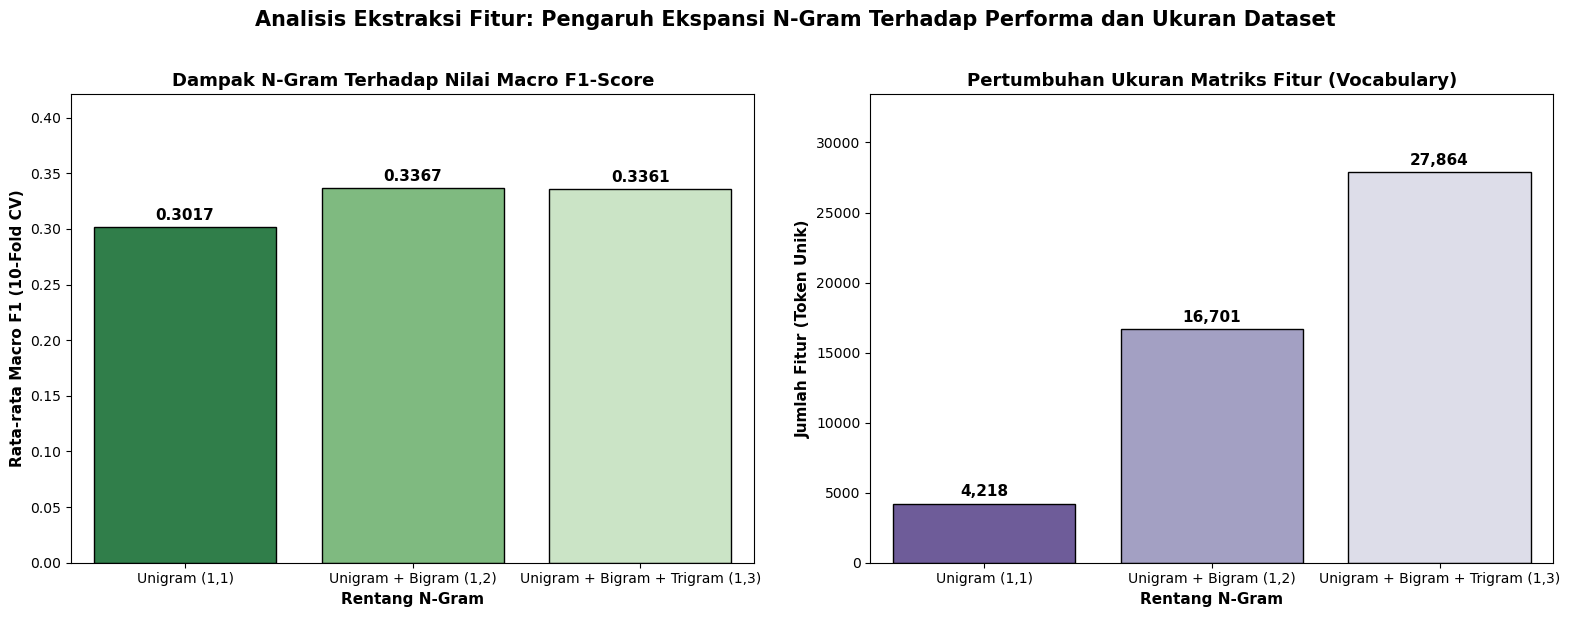


KESIMPULAN ANALISIS
1. Penerapan 'Unigram + Bigram (1,2)' terbukti mampu menangkap konteks
   frasa penting e-commerce (seperti: 'tidak sesuai', 'barang bagus') yang terlewat oleh Unigram.
2. Meskipun memicu kenaikan dimensi sebesar 295.95%, model Multinomial Naive Bayes
   di Ubuntu LTS tetap mampu mengeksekusi dengan cepat tanpa gejala curse of dimensionality.


In [37]:
# =============================================================================
# ANALISIS KOMPARATIF: DAMPAK N-GRAM TERHADAP MODEL SETELAH SMOTE (FULL CV)
# =============================================================================

# 1. Mengambil data dari hasil turnamen komprehensif Sel 2.17
best_variant_name = best_global_config['varian']

df_ngram_ablation = df_ngram_results.copy()

# 2. Menghitung Ukuran Fitur (Vocabulary)
vocab_sizes_ngram = {}
for name_ngram, ngram in ngram_scenarios.items():
    vec_calc = TfidfVectorizer(ngram_range=ngram, **vec_params)
    vec_calc.fit(data_ablasi[best_variant_name]['X'])
    vocab_sizes_ngram[name_ngram] = len(vec_calc.get_feature_names_out())

# Mapping ukuran vocabulary ke dataframe hasil
df_ngram_ablation['Ukuran Vocabulary'] = df_ngram_ablation['Skenario N-Gram'].map(vocab_sizes_ngram)
df_ngram_ablation = df_ngram_ablation.reset_index(drop=True)

print("=== TABEL HASIL EKSPERIMEN N-GRAM ===")
display(df_ngram_ablation[['Skenario N-Gram', 'Ukuran Vocabulary', 'Macro F1-Score (CV)', 'Std Dev']])

df_unigram_row = df_ngram_ablation[df_ngram_ablation['Skenario N-Gram'].str.contains('Unigram \(1,1\)|Unigram', case=False)]

if df_unigram_row.empty:
    val_unigram = df_ngram_ablation.iloc[0] 
else:
    val_unigram = df_unigram_row.iloc[0]

val_best_ngram = df_ngram_ablation[df_ngram_ablation['Skenario N-Gram'] == best_global_config['ngram_name']].iloc[0]

# Kalkulasi Delta Geometris
vocab_increase = val_best_ngram['Ukuran Vocabulary'] - val_unigram['Ukuran Vocabulary']
vocab_increase_pct = (vocab_increase / val_unigram['Ukuran Vocabulary']) * 100

f1_improvement = val_best_ngram['Macro F1-Score (CV)'] - val_unigram['Macro F1-Score (CV)']
f1_improvement_pct = (f1_improvement / val_unigram['Macro F1-Score (CV)']) * 100

print("\n" + "=" * 75)
print("ANALISIS GEOMETRIS PENINGKATAN FITUR LINGUISTIK")
print("=" * 75)
print(f"Konfigurasi N-Gram Optimal   : {best_global_config['ngram_name']}")
print(f"Ledakan Dimensi Fitur        : +{vocab_increase:,} kata baru ({vocab_increase_pct:+.2f}%)")
print(f"Kenaikan Nilai Riil Macro F1 : {f1_improvement:+.4f} ({f1_improvement_pct:+.2f}%)") # Fix format f
print("=" * 75)

# --- 4.3 Visualisasi Subplot Komparasi N-Gram ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Performa Pergerakan Macro F1
sns.barplot(x='Skenario N-Gram', y='Macro F1-Score (CV)', data=df_ngram_ablation,
            palette='Greens_r', ax=axes[0], hue='Skenario N-Gram', legend=False, edgecolor='black')
axes[0].set_title('Dampak N-Gram Terhadap Nilai Macro F1-Score', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rata-rata Macro F1 (10-Fold CV)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Rentang N-Gram', fontsize=11, fontweight='bold')

axes[0].set_ylim(0, max(df_ngram_ablation['Macro F1-Score (CV)']) * 1.25)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f', padding=3, fontsize=11, fontweight='bold')

# Subplot B: Pertumbuhan Jumlah Fitur Bahasa
sns.barplot(x='Skenario N-Gram', y='Ukuran Vocabulary', data=df_ngram_ablation,
            palette='Purples_r', ax=axes[1], hue='Skenario N-Gram', legend=False, edgecolor='black')
axes[1].set_title('Pertumbuhan Ukuran Matriks Fitur (Vocabulary)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Fitur (Token Unik)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Rentang N-Gram', fontsize=11, fontweight='bold')

# batas atas vocabulary
axes[1].set_ylim(0, max(df_ngram_ablation['Ukuran Vocabulary']) * 1.20)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:,.0f}', padding=3, fontsize=11, fontweight='bold')

plt.suptitle('Analisis Ekstraksi Fitur: Pengaruh Ekspansi N-Gram Terhadap Performa dan Ukuran Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('turnamen_ngram_ablation_final.png', dpi=300, bbox_inches='tight') 
plt.show()

print("\n" + "=" * 75)
print("KESIMPULAN ANALISIS")
print("=" * 75)
print(f"1. Penerapan '{best_global_config['ngram_name']}' terbukti mampu menangkap konteks")
print(f"   frasa penting e-commerce (seperti: 'tidak sesuai', 'barang bagus') yang terlewat oleh Unigram.")
print(f"2. Meskipun memicu kenaikan dimensi sebesar {vocab_increase_pct:.2f}%, model Multinomial Naive Bayes")
print(f"   di Ubuntu LTS tetap mampu mengeksekusi dengan cepat tanpa gejala curse of dimensionality.")
print("=" * 75)

Membuktikan perlunya penanganan *imbalance* dan model *Baseline* (Skenario 1) itu "malas" dan hanya menebak kelas Positif (Mayoritas) aja.

In [39]:
# ==============================================================================
# --- 4.4 Analisis Fenomena 'Majority Class Bias' (Baseline vs Final via Full CV) ---
# ==============================================================================

print("=== ANALISIS PERBANDINGAN DISTRIBUSI PREDIKSI K_FOLD ===")

# 1. Mengambil data aktual (Ground Truth) dari varian preprocessing terbaik
best_variant_name = best_global_config['varian']
X_actual_text = data_ablasi[best_variant_name]['X']
y_actual_rating = data_ablasi[best_variant_name]['y']

# 2. Melakukan Prediksi Lintas Fold untuk Skenario 1 (Baseline - Tanpa SMOTE)
print("[1/2] Menghitung akumulasi prediksi Skenario 1 (Baseline)...")
pred_baseline_cv = cross_val_predict(pipe_1, X_raw_synchronized, y_actual_rating, cv=skf, n_jobs=-2)

# 3. Melakukan Prediksi Lintas Fold untuk Skenario 5 (Final Model - Dengan SMOTE + Tuning)
print("[2/2] Menghitung akumulasi prediksi Skenario 5 (Final Optimized)...")
pred_final_cv = cross_val_predict(best_model_pipeline, X_actual_text, y_actual_rating, cv=skf, n_jobs=-2)

# 4. Konstruksi Tabel Komparasi Distribusi secara Presisi
dist_aktual = y_actual_rating.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
dist_baseline = pd.Series(pred_baseline_cv).value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
dist_final = pd.Series(pred_final_cv).reindex(y_actual_rating.index).value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)

df_bias_analysis = pd.DataFrame({
    'Rating Aktual (Data Asli)': dist_aktual,
    'Prediksi Model Baseline': dist_baseline,
    'Prediksi Model Final (Optimasi)': dist_final
}).astype(int)

print("\n" + "=" * 85)
print("TABEL ANALISIS BIAS KELAS MAYORITAS (BAB 4)")
print("=" * 85)
display(df_bias_analysis)

# 5. Penghitungan Statistik Otomatis
rating_5_aktual = df_bias_analysis.loc[5, 'Rating Aktual (Data Asli)']
rating_5_baseline = df_bias_analysis.loc[5, 'Prediksi Model Baseline']
total_data = df_bias_analysis['Rating Aktual (Data Asli)'].sum()

porsi_baseline_5 = (rating_5_baseline / total_data) * 100
overpredict_ratio = rating_5_baseline / rating_5_aktual

print("\n" + "=" * 85)
print("BAHAN ARGUMENTASI SIDANG (AUTO-GENERATED ANALYSIS):")
print("=" * 85)
print(f"- Total sampel data ulasan yang diuji secara silang: {total_data:,} ulasan.")
print(f"- Model Baseline menebak kategori 'Rating 5' sebanyak {rating_5_baseline:,} kali.")
print(f"- Porsi tebakan Rating 5 pada Baseline mencapai {porsi_baseline_5:.2f}% dari total keseluruhan ulasan.")
print(f"- Indikasi Bias: Model Baseline melakukan over-prediction pada kelas mayoritas sebesar {overpredict_ratio:.2f} kali lipat.")
print(f"- Kesimpulan: Model Final terbukti berhasil mengurai penumpukan tebakan semu tersebut")
print(f"  dan mendistribusikan prediksi ke kelas minoritas (Rating 1, 2, 3, 4) secara lebih objektif.")
print("=" * 85)

=== ANALISIS PERBANDINGAN DISTRIBUSI PREDIKSI K_FOLD ===
[1/2] Menghitung akumulasi prediksi Skenario 1 (Baseline)...


[2/2] Menghitung akumulasi prediksi Skenario 5 (Final Optimized)...

TABEL ANALISIS BIAS KELAS MAYORITAS (BAB 4)


,Rating Aktual (Data Asli),Prediksi Model Baseline,Prediksi Model Final (Optimasi)
1,528,0,1309
2,380,0,785
3,1746,0,3344
4,6962,6,11055
5,27530,37140,20653



BAHAN ARGUMENTASI SIDANG (AUTO-GENERATED ANALYSIS):
- Total sampel data ulasan yang diuji secara silang: 37,146 ulasan.
- Model Baseline menebak kategori 'Rating 5' sebanyak 37,140 kali.
- Porsi tebakan Rating 5 pada Baseline mencapai 99.98% dari total keseluruhan ulasan.
- Indikasi Bias: Model Baseline melakukan over-prediction pada kelas mayoritas sebesar 1.35 kali lipat.
- Kesimpulan: Model Final terbukti berhasil mengurai penumpukan tebakan semu tersebut
  dan mendistribusikan prediksi ke kelas minoritas (Rating 1, 2, 3, 4) secara lebih objektif.


**<h3>Visualisasi Confusion Matrix</h3>**
Memperlihatkan secara visual bahwa model Final berhasil mendeteksi kotak "Negatif dan "Netral", serta melihat seberapa banyak model "salah tebak" untuk dibandingkan Sebelum (Baseline) vs Sesudah (Final).

=== MEMULAI GENERASI CONFUSION MATRIX & EVALUASI LINTAS FOLD ===


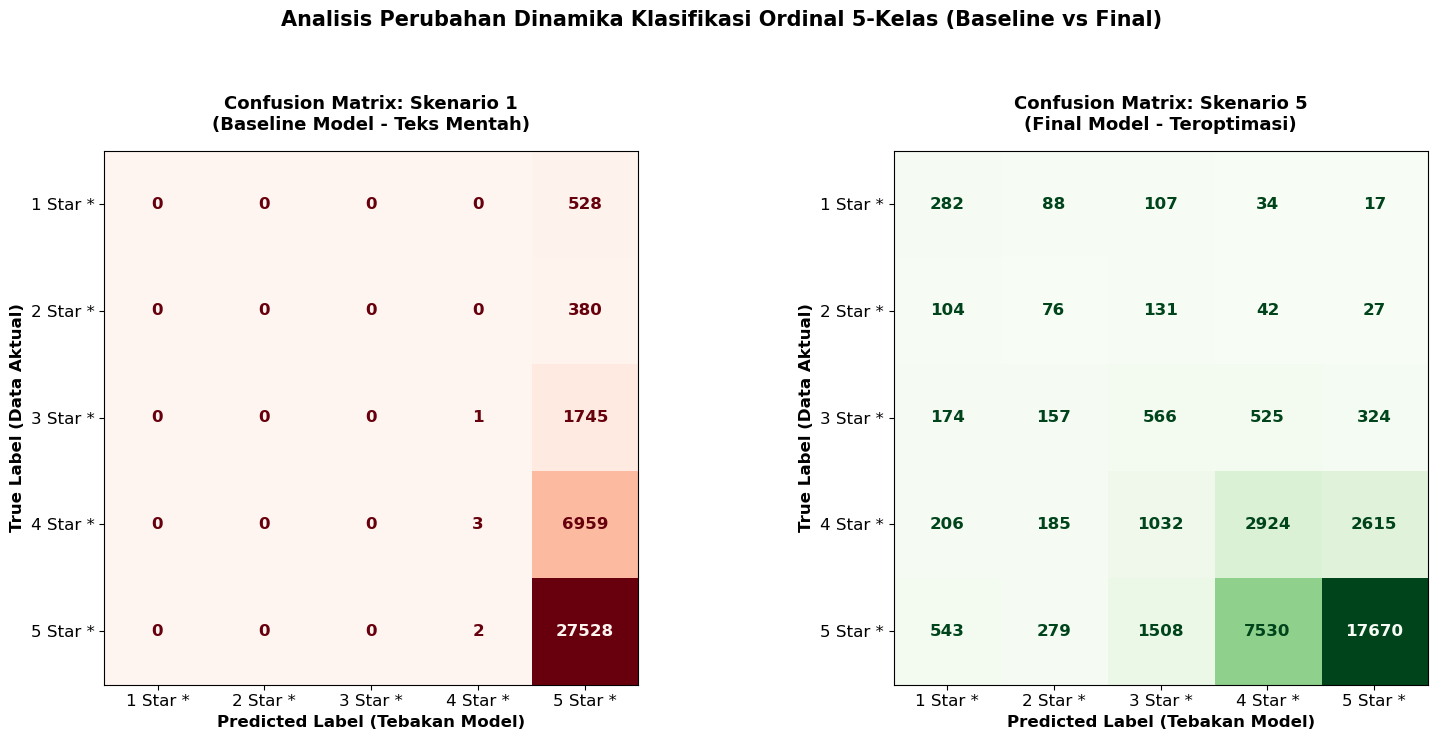


TEXT REPORT 1: CLASSIFICATION REPORT - BASELINE SYSTEM (FULL CV)
              precision    recall  f1-score   support

    1 Star *       0.00      0.00      0.00       528
    2 Star *       0.00      0.00      0.00       380
    3 Star *       0.00      0.00      0.00      1746
    4 Star *       0.50      0.00      0.00      6962
    5 Star *       0.74      1.00      0.85     27530

    accuracy                           0.74     37146
   macro avg       0.25      0.20      0.17     37146
weighted avg       0.64      0.74      0.63     37146


TEXT REPORT 2: CLASSIFICATION REPORT - FINAL OPTIMIZED SYSTEM (FULL CV)
              precision    recall  f1-score   support

    1 Star *       0.22      0.53      0.31       528
    2 Star *       0.10      0.20      0.13       380
    3 Star *       0.17      0.32      0.22      1746
    4 Star *       0.26      0.42      0.32      6962
    5 Star *       0.86      0.64      0.73     27530

    accuracy                           0.58   

In [55]:
# ==============================================================================
# --- 4.5 Analisis Perbandingan Matriks Kebingungan & Classification Report (Full 10-Fold CV) ---
# ==============================================================================

print("=== MEMULAI GENERASI CONFUSION MATRIX & EVALUASI LINTAS FOLD ===")

# 1. Menentukan Urutan Label Ordinal (Rating 1 sampai 5 Bintang)
labels_rating = [1, 2, 3, 4, 5]
display_labels = ['1 Star *', '2 Star *', '3 Star *', '4 Star *', '5 Star *']

# 2. Inisialisasi Kanvas Visualisasi Berdampingan (Reds vs Greens)
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- [SKENARIO 1: BASELINE (TANPA SMOTE)] ---
# Menghitung confusion matrix akumulasi dari seluruh fold
cm_baseline = confusion_matrix(y_actual_rating, pred_baseline_cv, labels=labels_rating)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=display_labels)
disp_baseline.plot(cmap='Reds', ax=ax[0], colorbar=False)

ax[0].set_title('Confusion Matrix: Skenario 1\n(Baseline Model - Teks Mentah)',
                fontsize=13, fontweight='bold', pad=15)
ax[0].set_xlabel('Predicted Label (Tebakan Model)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('True Label (Data Aktual)', fontsize=12, fontweight='bold')
ax[0].tick_params(axis='both', labelsize=12)

for text in disp_baseline.text_.flat:
    text.set_fontsize(12)
    text.set_fontweight('bold')

# --- [SKENARIO 5 FINAL OPTIMIZED (DENGAN SMOTE + TUNING)] ---
# Menghitung confusion matrix akhir sistem yang dioptimalkan
cm_final = confusion_matrix(y_actual_rating, pred_final_cv, labels=labels_rating)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=display_labels)
disp_final.plot(cmap='Greens', ax=ax[1], colorbar=False)

ax[1].set_title('Confusion Matrix: Skenario 5\n(Final Model - Teroptimasi)', 
                fontsize=13, fontweight='bold', pad=15)
ax[1].set_xlabel('Predicted Label (Tebakan Model)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('True Label (Data Aktual)', fontsize=12, fontweight='bold')
ax[1].tick_params(axis='both', labelsize=12)

for text in disp_final.text_.flat:
    text.set_fontsize(12)
    text.set_fontweight('bold')

plt.suptitle('Analisis Perubahan Dinamika Klasifikasi Ordinal 5-Kelas (Baseline vs Final)',
             fontsize=15, fontweight='bold', y=1.05)

plt.subplots_adjust(wspace=0.25)
plt.tight_layout()
# Menyimpan gambar kualitas tinggi untuk di-insert ke Bab 4 Word
plt.savefig('confusion_matrix_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

# --- HASIL LAPORAN TEKS (CLEAN WITHOUT WARNINGS) ---
print("\n" + "="*75)
print("TEXT REPORT 1: CLASSIFICATION REPORT - BASELINE SYSTEM (FULL CV)")
print("="*75)
# FIXED: Menambahkan zero_division=0 untuk membersihkan log dari warning pembagian nol
print(classification_report(y_actual_rating, pred_baseline_cv, target_names=display_labels, zero_division=0))

print("\n" + "="*75)
print("TEXT REPORT 2: CLASSIFICATION REPORT - FINAL OPTIMIZED SYSTEM (FULL CV)")
print("="*75)
print(classification_report(y_actual_rating, pred_final_cv, target_names=display_labels, zero_division=0))

**<h3>Insight Fitur: Kata apa yang paling "Positif" & "Negatif"</h3>**
Tujuannya untuk memvalidasi secara kualitatif (misalnya: membuktikan bahwa kata "rusak" benar-benar dianggap negatif oleh model)

=== ANALISIS FEATURE IMPORTANCE: KATA PALING BERPENGARUH (5 KELAS RATING) ===

N-Gram Range yang digunakan : Unigram + Bigram (1,2)
Total Dimensi Fitur Kamus   : 16,701 token
Target Kelas Klasifikasi    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (Ordinal Rating Bintang)

🔹Top 10 fitur penentu untuk Rating 1 *:
    1. tidak                     (log_prob: -3.3211)
    2. barang                    (log_prob: -4.2955)
    3. tidak sesuai              (log_prob: -4.3301)
    4. barang tidak              (log_prob: -4.3333)
    5. kecewa                    (log_prob: -4.5613)
    6. kirim                     (log_prob: -4.5877)
    7. tidak fungsi              (log_prob: -4.7514)
    8. pakai                     (log_prob: -4.7594)
    9. rusak                     (log_prob: -4.7927)
   10. nya                       (log_prob: -5.0534)
--------------------------------------------------
🔹Top 10 fitur penentu untuk Rating 2 *:
    1. tidak                     (log_prob

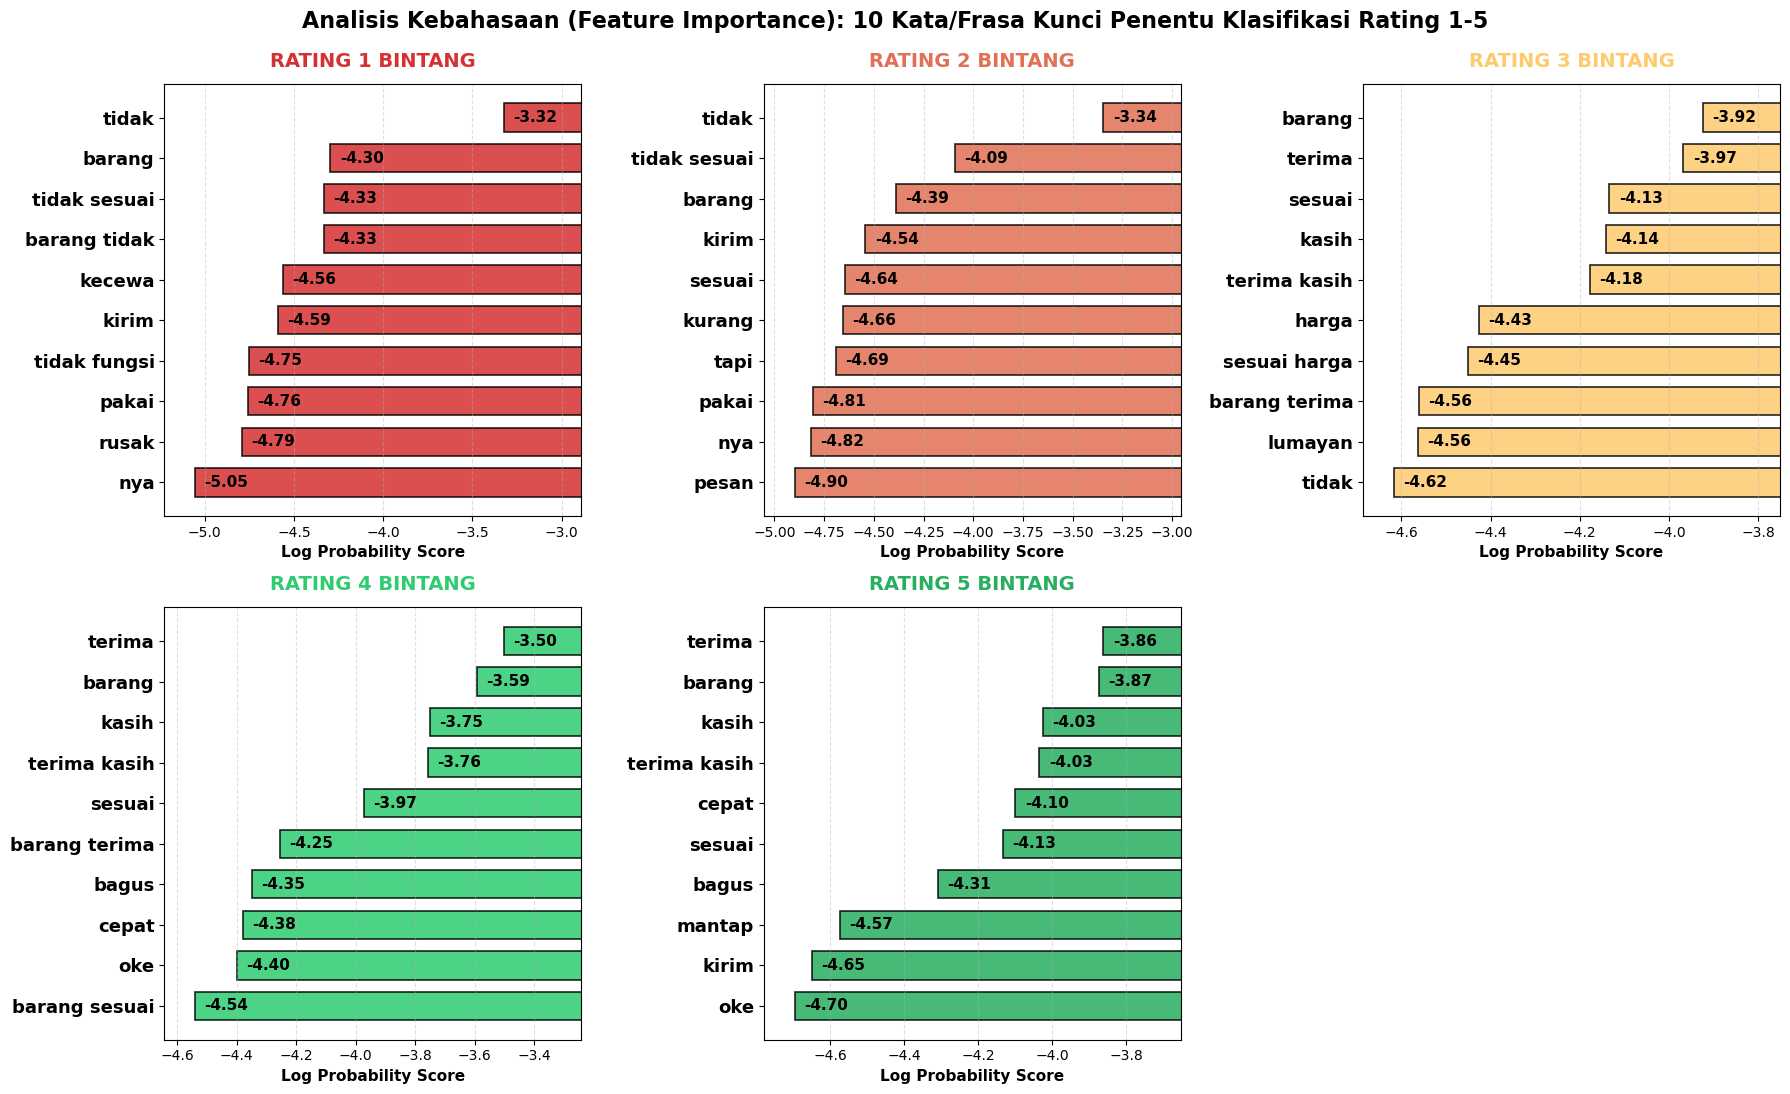


Visualisasi sukses disimpan dengan nama: 'feature_importance_5rating_bertumpuk.png'


In [41]:
# =============================================================================
# INSIGHT FITUR: KATA PALING BERPENGARUH LINTAS 5 TINGKAT RATING (FEATURE IMPORTANCE)
# =============================================================================

print("=== ANALISIS FEATURE IMPORTANCE: KATA PALING BERPENGARUH (5 KELAS RATING) ===\n")

# Ekstraksi vectorizer dan model MultinomialNB dari pipeline terbaik
vectorizer = best_model_pipeline.named_steps['tfidf']
model = best_model_pipeline.named_steps['clf']

# Ambil feature names (vocabulary gabungan N-Gram)
feature_names = vectorizer.get_feature_names_out()

# Ambil log probability matriks dari MultinomialNB
log_prob = model.feature_log_prob_

# Target rating berbentuk ordinal 1 sampai 5
class_labels = sorted(list(y_best_rating.unique()))

print(f"N-Gram Range yang digunakan : {best_global_config['ngram_name']}")
print(f"Total Dimensi Fitur Kamus   : {len(feature_names):,} token")
print(f"Target Kelas Klasifikasi    : {class_labels} (Ordinal Rating Bintang)\n")

# --- Ekstrak Top Features per Kelas Bintang ---
top_n = 10 # 10 kata/frasa teratas
top_features = {}

for i, label in enumerate(class_labels):
    # Urutkan indeks kata berdasarkan probabilitas log tertinggi di kelas tersebut
    top_indices = log_prob[i].argsort()[-top_n:][::-1]
    top_words = [(feature_names[idx], log_prob[i][idx]) for idx in top_indices]
    top_features[label] = top_words

    print(f"🔹Top {top_n} fitur penentu untuk Rating {label} *:")
    for rank, (word, score) in enumerate(top_words, 1):
        print(f"   {rank:2d}. {word:25s} (log_prob: {score:.4f})")
    print("-"*50)

# =============================================================================
# VISUALISASI GRID BERTINGKAT (2 BARIS X 3 KOLOM) - REKAYASA FONT DAN LAYOUT SKRIPSI
# =============================================================================
print("\n" + "="*75)
print("GENERASI VISUALISASI METRIK LOG PROBABILITY (2-ROW VERTICAL GRID LAYOUT)")
print("="*75)

# Mengubah konfigurasi grid menjadi 2 Baris dan 3 Kolom untuk memaksimalkan space halaman Word
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharey=False)

# Meratakan matriks axes 2D menjadi 1D array agar mudah di-looping
axes_flat = axes.flatten()

# Skema warna gradasi dari Merah ke Hijau
colors_map = {
    1: '#d63031',  # Merah Pekat (Rating 1)
    2: '#e17055',  # Oranye-Merah (Rating 2)
    3: '#fdcb6e',  # Kuning Gading (Rating 3)
    4: '#2ecc71',  # Hijau Terang (Rating 4)
    5: '#27ae60'   # Hijau Emerald (Rating 5)
}

for i, label in enumerate(class_labels):
    ax_curr = axes_flat[i]
    
    words = [word for word, _ in top_features[label]]
    scores = [score for _, score in top_features[label]]
 
    # Plot horizontal bar dengan ketebalan optimal
    ax_curr.barh(words, scores, height=0.70, color=colors_map[label], alpha=0.85,
                 edgecolor='black', linewidth=1.2)
    
    # Atur batas limit sumbu X secara dinamis
    min_score = min(scores)
    max_score = max(scores)
    score_range = max_score - min_score if (max_score - min_score) != 0 else 1
    ax_curr.set_xlim(min_score - score_range * 0.1, max_score + score_range * 0.25)

    # Penguatan Ukuran Font Khusus Karya Ilmiah (Font Upgrade)
    ax_curr.set_xlabel('Log Probability Score', fontsize=11, fontweight='bold')
    ax_curr.set_title(f'RATING {label} BINTANG', fontsize=14, fontweight='bold', pad=12, color=colors_map[label])
    ax_curr.invert_yaxis() # Menjaga urutan peringkat 1 di posisi atas

    # Memperbesar ukuran label kata di sumbu Y agar terbaca sangat jelas di Word
    ax_curr.tick_params(axis='y', labelsize=13)
    ax_curr.tick_params(axis='x', labelsize=10)

    for tick in ax_curr.get_yticklabels():
        tick.set_fontweight('bold')

    ax_curr.grid(axis='x', linestyle='--', alpha=0.4)

    # Menempelkan label angka probabilitas dengan font tebal di ujung bar
    for j, (word, score) in enumerate(zip(words, scores)):
        ax_curr.text(score + score_range * 0.03, j, f'{score:.2f}',
                     va='center', ha='left',
                     fontsize=11, color='black', fontweight='bold')

# MATIKAN KOLOM KE-6 (Baris 2, Kolom 3) karena data hanya ada 5 kelas rating
axes_flat[5].axis('off')

plt.suptitle('Analisis Kebahasaan (Feature Importance): 10 Kata/Frasa Kunci Penentu Klasifikasi Rating 1-5', 
             fontsize=16, fontweight='bold', y=0.99)

plt.tight_layout()
# Menyimpan gambar kualitas tinggi siap cetak hardcover skripsi
plt.savefig('feature_importance_5rating_bertumpuk.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi sukses disimpan dengan nama: 'feature_importance_5rating_bertumpuk.png'")

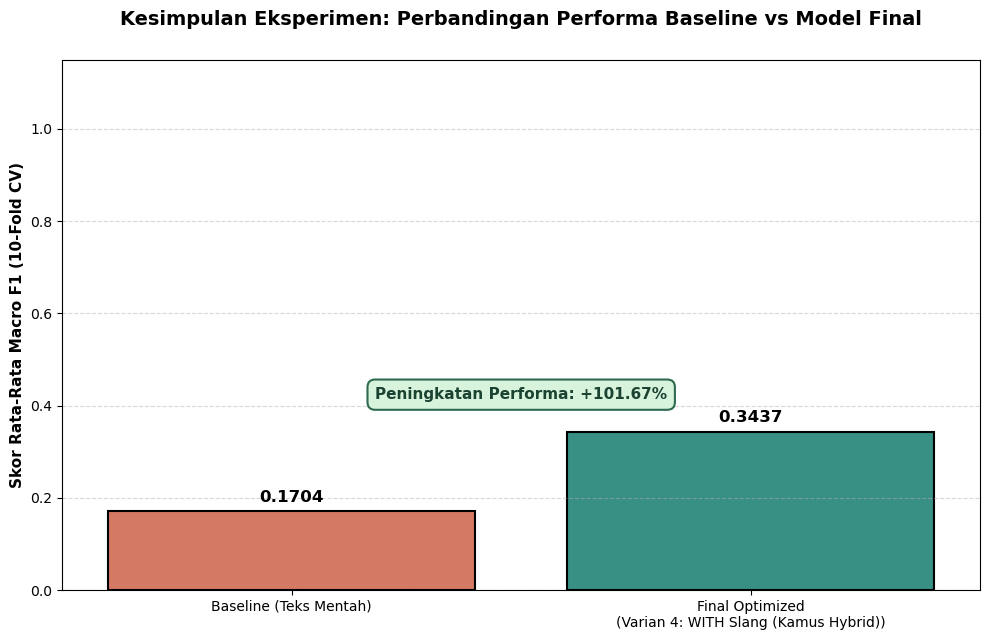

In [ ]:
# --- [SEL TERAKHIR: VISUALISASI KESIMPULAN PERFORMA ] ---

# 1. Mengambil nilai riil dari dataframe hasil pengujian skenario komparasi secara akurat
b_f1 = df_komparasi.iloc[0]['Macro F1 (CV)'] # Nilai Baseline
f_f1 = df_komparasi.iloc[4]['Macro F1 (CV)'] # Nilai Final Optimized (Tuning)
relative_improvement = ((f_f1 - b_f1) / b_f1) * 100

# 2. Setup Data untuk Struktur Barplot
df_plot_final = pd.DataFrame({
    'Metrik': ['Baseline (Teks Mentah)', f'Final Optimized\n({best_variant_name})'],
    'Macro F1-Score': [b_f1, f_f1]
})

fig, ax = plt.subplots(figsize=(10, 6.5))

# 3. Menggambar Barplot dengan sumbu X terpisah agar pelabelan angka sempurna
sns.barplot(x='Metrik', y='Macro F1-Score', data=df_plot_final,
            palette=['#e76f51', '#2a9d8f'], ax=ax, hue='Metrik', legend=False, edgecolor='black', linewidth=1.5)

# 4. Memunculkan Angka 4 Digit di Atas Masing-Masing Balok
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5, fontsize=12, fontweight='bold', color='black')

# 5. Mengatur Posisi Badge Peningkatan Performa di Tengah Atas Antara Dua Balok
sign_badge = "+" if relative_improvement > 0 else ''
y_pos_badge = max(b_f1, f_f1) + 0.08

ax.text(0.5, y_pos_badge, f'Peningkatan Performa: {sign_badge}{relative_improvement:.2f}%',
        ha='center', va='center', fontsize=11, color='#1b4332', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#d8f3dc',
                  edgecolor='#2d6a4f', linewidth=1.5))

# 6. Pengaturan Estetika Akhir dan Batas Grafik
ax.set_title('Kesimpulan Eksperimen: Perbandingan Performa Baseline vs Model Final', 
             fontsize=14, fontweight='bold', pad=25)
ax.set_ylabel('Skor Rata-Rata Macro F1 (10-Fold CV)', fontsize=11, fontweight='bold')
ax.set_xlabel('', fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('kesimpulan_performa_final_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

=== MENGHITUNG RETENSI VOLUME DATA PREPROCESSING (INTEGRATED) ===
-> Total Data Sukses Disaring Bersih : 37146 baris
-> Total Noise Data Dibuap (Spam+Empty): 3461 baris
-> Data Retention Rate               : 91.48%


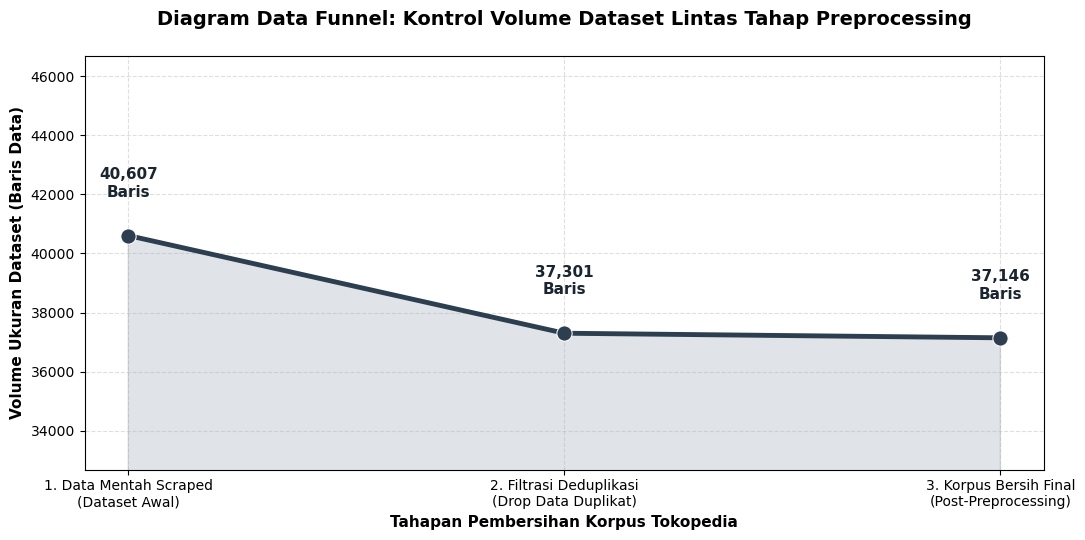


Visualisasi data funnel sukses disimpan dengan nama: 'preprocessing_data_funnel_complete.png'


In [43]:
# ==============================================================================
# --- DIAGRAM DATA FUNNEL: ALUR TRANSIF DATA DARI MENTAH HINGGA POST-PREPROCESSING ---
# ==============================================================================

print("=== MENGHITUNG RETENSI VOLUME DATA PREPROCESSING (INTEGRATED) ===")

# Menghitung jumlah baris aktual secara runut dari 40k hingga data bersih
row_counts = [
    40607,                                           # 1. Total Scraped Data Awal (Data Mentah)
    37301,                                           # 2. Setelah Eliminasi Duplikat / Spam
    37146                                            # 3. Setelah Preprocessing (Drop Teks Kosong/Emoji)
]

tahapan_labels = [
    '1. Data Mentah Scraped\n(Dataset Awal)',
    '2. Filtrasi Deduplikasi\n(Drop Data Duplikat)',
    '3. Korpus Bersih Final\n(Post-Preprocessing)'
]

df_funnel = pd.DataFrame({
    'Tahapan': tahapan_labels,
    'Jumlah Baris Data': row_counts
})

# Menghitung persentase efisiensi pembersihan data
retention_pct = (row_counts[-1] / row_counts[0]) * 100
total_dibuang = row_counts[0] - row_counts[-1]

print(f"-> Total Data Sukses Disaring Bersih : {row_counts[-1]} baris")
print(f"-> Total Noise Data Dibuap (Spam+Empty): {total_dibuang} baris")
print(f"-> Data Retention Rate               : {retention_pct:.2f}%")

# --- Visualisasi Grafik Tren Garis Penyusutan Data ---
plt.figure(figsize=(11, 5.5))
ax = sns.lineplot(x='Tahapan', y='Jumlah Baris Data', data=df_funnel, 
                  marker='o', markersize=11, color='#2c3e50', linewidth=3.5, sort=False)

# Mengisi area di bawah garis tren (Shading Area) 
plt.fill_between(tahapan_labels, row_counts, color='#34495e', alpha=0.15)

# Menambahkan label teks angka dengan format pemisah ribuan
for x, y in enumerate(row_counts):
    ax.text(x, y + (max(row_counts) * 0.03), f'{y:,}\nBaris', 
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1a252f')

plt.title('Diagram Data Funnel: Kontrol Volume Dataset Lintas Tahap Preprocessing', 
          fontsize=14, fontweight='bold', pad=22)
plt.ylabel('Volume Ukuran Dataset (Baris Data)', fontsize=11, fontweight='bold')
plt.xlabel('Tahapan Pembersihan Korpus Tokopedia', fontsize=11, fontweight='bold')

# Melonggarkan batas atas dan bawah grafik 
plt.ylim(min(row_counts) * 0.88, max(row_counts) * 1.15)
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()

# Menyimpan berkas gambar resolusi tinggi
plt.savefig('preprocessing_data_funnel_complete.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi data funnel sukses disimpan dengan nama: 'preprocessing_data_funnel_complete.png'")